<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>29 $\rightarrow$ English to French Translation using LSTMs</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">(Sequence to Sequence Translation with Keras & LSTM)</span>
</div>


---

# Table of Contents 

1. [Task 1: Understand the Problem Statement and Business Case](#task-1)
2. [Task 2: Import Libraries and Datasets](#task-2)
   - 2.1 [Mini Challenge #1](#mini-challenge-1)
   - 2.2 [Mini Challenge #2](#mini-challenge-2)
3. [Task 3: Perform Data Cleaning](#task-3)
   - 3.1 [Mini Challenge #3](#mini-challenge-3)
4. [Task 4: Visualize Cleaned Up Dataset](#task-4)
   - 4.1 [Mini Challenge #4 (QUIZ!)](#mini-challenge-4)
5. [Task 5: Prepare the Data by Performing Tokenization and Padding](#task-5)
   - 5.1 [Mini Challenge #5](#mini-challenge-5)
6. [Task 6: Understand the Theory and Intuition Behind Recurrent Neural Networks and LSTM](#task-6)
7. [Task 7: Understand the Intuition Behind Long Short Term Memory (LSTM) Networks](#task-7)
8. [Task 8: Build and Train the Model](#task-8)
   - 8.1 [Mini Challenge #6](#mini-challenge-6)
9. [Task 9: Assess Trained Model Performance](#task-9)
   - 9.1 [Interactive Quiz, Missing Code & Translation Puzzle](#task-9-quiz)
10. [Practice Solutions (Congratulations!)](#practice-solutions)
   - 10.1 [Mini Challenge #1 Solution](#solution-1)
   - 10.2 [Mini Challenge #2 Solution](#solution-2)
   - 10.3 [Mini Challenge #3 Solution](#solution-3)
   - 10.4 [Mini Challenge #4 Solution](#solution-4)
   - 10.5 [Mini Challenge #5 Solution](#solution-5)
   - 10.6 [Mini Challenge #6 Solution](#solution-6)

---


<a id="task-1"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 1: Understand the Problem Statement and Business Case</span>

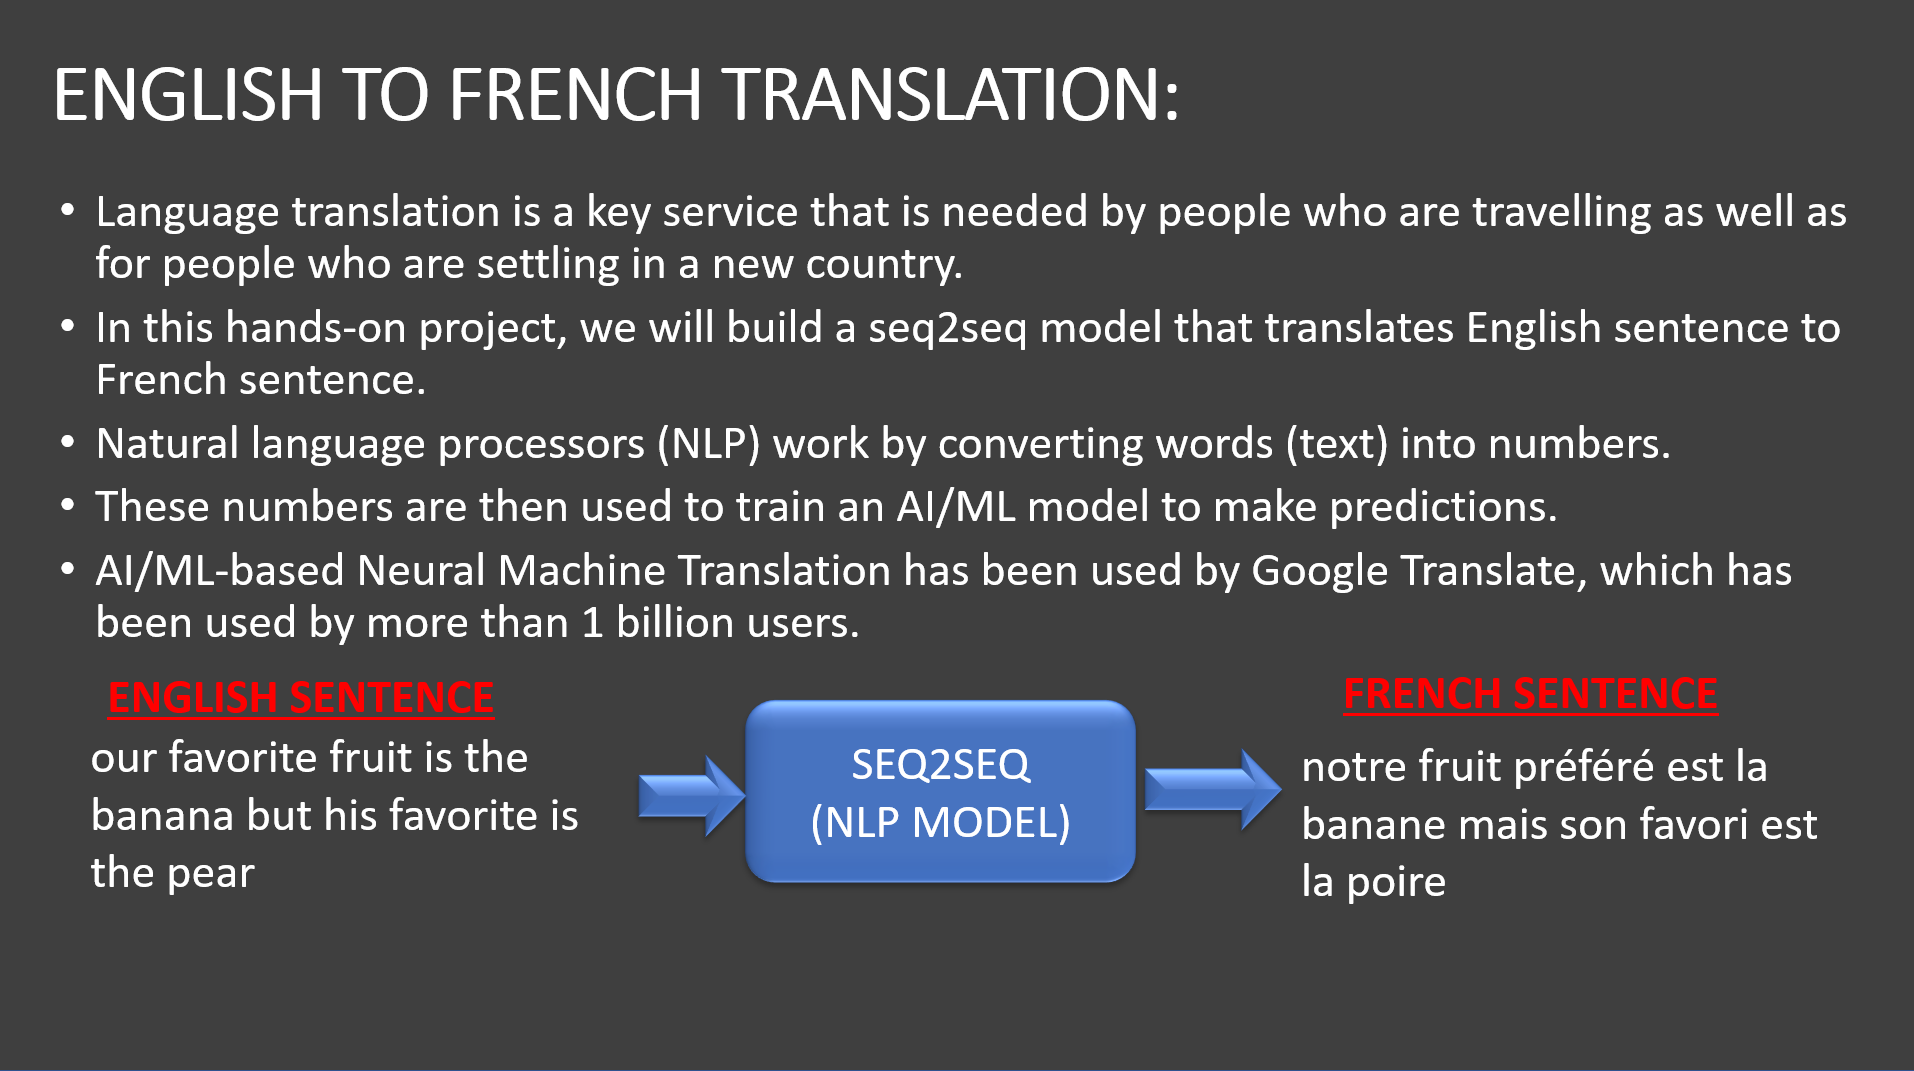

<a id="task-2"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 2: Import Libraries and Datasets</span>

In [14]:
# TensorFlow installation check
# Modern TensorFlow automatically leverages GPU acceleration if compatible hardware/CUDA is detected.
# !pip install --quiet tensorflow


In [ ]:
# Install supplementary NLP & visualization libraries if not already present
!pip install --quiet nltk plotly wordcloud

In [ ]:
import nltk
nltk.download('punkt', quiet=True)

True

In [17]:
!pip install gensim -q
!pip install jupyterthemes -q

In [18]:
from collections import Counter
import operator
import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import nltk
import re
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
import gensim
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
from tensorflow.keras.preprocessing.text import one_hot, Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, TimeDistributed, RepeatVector, Embedding, Input, LSTM, Conv1D, MaxPool1D, Bidirectional
from tensorflow.keras.optimizers import Adam
from jupyterthemes import jtplot
jtplot.style(theme='monokai', context='notebook', ticks=True, grid=False) 
# setting the style of the notebook to be monokai theme  
# this line of code is important to ensure that we are able to see the x and y axes clearly
# If you don't run this code line, you will notice that the xlabel and ylabel on any plot is black on black and it will be hard to see them.

In [19]:
# Load the dataset from the data/ folder (with fallback to local directory)
import os

data_path_en = 'data/small_vocab_en.csv' if os.path.exists('data/small_vocab_en.csv') else 'small_vocab_en.csv'
data_path_fr = 'data/small_vocab_fr.csv' if os.path.exists('data/small_vocab_fr.csv') else 'small_vocab_fr.csv'

df_english = pd.read_csv(data_path_en, sep='/t', names=['english'], engine='python', encoding='utf-8')
df_french = pd.read_csv(data_path_fr, sep='/t', names=['french'], engine='python', encoding='utf-8')


/tmp/ipykernel_7912/3214129257.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_english = pd.read_csv('small_vocab_en.csv', sep = '/t', names = ['english'])


FileNotFoundError: [Errno 2] No such file or directory: 'small_vocab_en.csv'

<a id="mini-challenge-1"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">Mini Challenge #1</span>

- Explore the 'english' and 'french' data and indicate how many samples are included.
- Do we have Null elements? What are the memory usage for both dataframes?

In [ ]:
# Mini Challenge #1: Explore dataset shape, nulls, and memory usage
print(f"English Dataset Samples: {len(df_english):,} | Null count: {df_english.isnull().sum().values[0]}")
print(f"French Dataset Samples:  {len(df_french):,} | Null count: {df_french.isnull().sum().values[0]}")
print("\n--- Memory Usage ---")
print("English DataFrame Memory:", df_english.memory_usage(deep=True).sum() / 1024, "KB")
print("French DataFrame Memory: ", df_french.memory_usage(deep=True).sum() / 1024, "KB")


<a id="mini-challenge-2"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">Mini Challenge #2</span>

- Concatenate both dataframes and indicate how many records are present
- Print out the following: "Total English Records = xx, Total French Records = xx"

In [ ]:
# Concatenate english and french 
df = pd.concat([df_english, df_french], axis = 1)
df

,english,french
0,"new jersey is sometimes quiet during autumn , ...",new jersey est parfois calme pendant l' automn...
1,the united states is usually chilly during jul...,les Ã©tats-unis est gÃ©nÃ©ralement froid en ju...
2,"california is usually quiet during march , and...","california est gÃ©nÃ©ralement calme en mars , ..."
3,the united states is sometimes mild during jun...,"les Ã©tats-unis est parfois lÃ©gÃ¨re en juin ,..."
4,"your least liked fruit is the grape , but my l...","votre moins aimÃ© fruit est le raisin , mais m..."
...,...,...
137855,"france is never busy during march , and it is ...","la france est jamais occupÃ©e en mars , et il ..."
137856,"india is sometimes beautiful during spring , a...","l' inde est parfois belle au printemps , et il..."
137857,"india is never wet during summer , but it is s...","l' inde est jamais mouillÃ© pendant l' Ã©tÃ© ,..."
137858,"france is never chilly during january , but it...","la france est jamais froid en janvier , mais i..."


In [ ]:
print("Total English Records = {}".format(len(df['english'])))
print("Total French Records = {}".format(len(df['french'])))

Total English Records = 137860
Total French Records = 137860


<a id="task-3"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 3: Perform Data Cleaning</span>

In [ ]:
# download nltk packages
nltk.download('punkt')

# download stopwords
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# function to remove punctuations
def remove_punc(x):
  return re.sub('[!#?,.:";]', '', x)

In [ ]:
df['french'] = df['french'].apply(remove_punc)
df['english'] = df['english'].apply(remove_punc)

In [ ]:
english_words = []
french_words  = []

<a id="mini-challenge-3"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">Mini Challenge #3</span>

- How many unique words are available in the english and french dictionairies?


In [ ]:
# function to get the list of unique words
def get_label_superset(x, word_list):
    for label in x.split():
        if label not in word_list:
            word_list.append(label)
            
df['english'].apply(lambda x: get_label_superset(x, english_words))
df['french'].apply(lambda x: get_label_superset(x, french_words))

# number of unique words in english
total_english_words  = len(english_words)
total_english_words



199

In [ ]:
# number of unique words in french
total_french_words = len(french_words)
total_french_words

350

<a id="task-4"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 4: Visualize Cleaned Up Dataset</span>

In [ ]:
# Obtain list of all words in the dataset
words = []
for i in df['english']:
  for word in i.split():
    words.append(word)
    
words

['new',
 'jersey',
 'is',
 'sometimes',
 'quiet',
 'during',
 'autumn',
 'and',
 'it',
 'is',
 'snowy',
 'in',
 'april',
 'the',
 'united',
 'states',
 'is',
 'usually',
 'chilly',
 'during',
 'july',
 'and',
 'it',
 'is',
 'usually',
 'freezing',
 'in',
 'november',
 'california',
 'is',
 'usually',
 'quiet',
 'during',
 'march',
 'and',
 'it',
 'is',
 'usually',
 'hot',
 'in',
 'june',
 'the',
 'united',
 'states',
 'is',
 'sometimes',
 'mild',
 'during',
 'june',
 'and',
 'it',
 'is',
 'cold',
 'in',
 'september',
 'your',
 'least',
 'liked',
 'fruit',
 'is',
 'the',
 'grape',
 'but',
 'my',
 'least',
 'liked',
 'is',
 'the',
 'apple',
 'his',
 'favorite',
 'fruit',
 'is',
 'the',
 'orange',
 'but',
 'my',
 'favorite',
 'is',
 'the',
 'grape',
 'paris',
 'is',
 'relaxing',
 'during',
 'december',
 'but',
 'it',
 'is',
 'usually',
 'chilly',
 'in',
 'july',
 'new',
 'jersey',
 'is',
 'busy',
 'during',
 'spring',
 'and',
 'it',
 'is',
 'never',
 'hot',
 'in',
 'march',
 'our',
 'leas

In [ ]:
# Obtain the total count of words
english_words_counts = Counter(words)
english_words_counts

Counter({'new': 12197,
         'jersey': 11225,
         'is': 205858,
         'sometimes': 37746,
         'quiet': 8693,
         'during': 74933,
         'autumn': 9004,
         'and': 59850,
         'it': 75137,
         'snowy': 8898,
         'in': 75525,
         'april': 8954,
         'the': 67628,
         'united': 11270,
         'states': 11270,
         'usually': 37507,
         'chilly': 8770,
         'july': 8956,
         'freezing': 8928,
         'november': 8951,
         'california': 11250,
         'march': 9023,
         'hot': 8639,
         'june': 9133,
         'mild': 8743,
         'cold': 8878,
         'september': 8958,
         'your': 9734,
         'least': 27564,
         'liked': 14046,
         'fruit': 27192,
         'grape': 4848,
         'but': 63987,
         'my': 9700,
         'apple': 4848,
         'his': 9700,
         'favorite': 28332,
         'orange': 4848,
         'paris': 11334,
         'relaxing': 8696,
         'decem

In [ ]:
# sort the dictionary by values
english_words_counts = sorted(english_words_counts.items(), key = operator.itemgetter(1), reverse = True)

In [ ]:
english_words_counts

[('is', 205858),
 ('in', 75525),
 ('it', 75137),
 ('during', 74933),
 ('the', 67628),
 ('but', 63987),
 ('and', 59850),
 ('sometimes', 37746),
 ('usually', 37507),
 ('never', 37500),
 ('favorite', 28332),
 ('least', 27564),
 ('fruit', 27192),
 ('most', 14934),
 ('loved', 14166),
 ('liked', 14046),
 ('new', 12197),
 ('paris', 11334),
 ('india', 11277),
 ('united', 11270),
 ('states', 11270),
 ('california', 11250),
 ('jersey', 11225),
 ('france', 11170),
 ('china', 10953),
 ('he', 10786),
 ('she', 10786),
 ('grapefruit', 10692),
 ('your', 9734),
 ('my', 9700),
 ('his', 9700),
 ('her', 9700),
 ('fall', 9134),
 ('june', 9133),
 ('spring', 9102),
 ('january', 9090),
 ('winter', 9038),
 ('march', 9023),
 ('autumn', 9004),
 ('may', 8995),
 ('nice', 8984),
 ('september', 8958),
 ('july', 8956),
 ('april', 8954),
 ('november', 8951),
 ('summer', 8948),
 ('december', 8945),
 ('february', 8942),
 ('our', 8932),
 ('their', 8932),
 ('freezing', 8928),
 ('pleasant', 8916),
 ('beautiful', 8915),
 ('

In [ ]:
# append the values to a list for visualization purposes
english_words = []
english_counts = []
for i in range(len(english_words_counts)):
  english_words.append(english_words_counts[i][0])
  english_counts.append(english_words_counts[i][1])

In [ ]:
english_words

['is',
 'in',
 'it',
 'during',
 'the',
 'but',
 'and',
 'sometimes',
 'usually',
 'never',
 'favorite',
 'least',
 'fruit',
 'most',
 'loved',
 'liked',
 'new',
 'paris',
 'india',
 'united',
 'states',
 'california',
 'jersey',
 'france',
 'china',
 'he',
 'she',
 'grapefruit',
 'your',
 'my',
 'his',
 'her',
 'fall',
 'june',
 'spring',
 'january',
 'winter',
 'march',
 'autumn',
 'may',
 'nice',
 'september',
 'july',
 'april',
 'november',
 'summer',
 'december',
 'february',
 'our',
 'their',
 'freezing',
 'pleasant',
 'beautiful',
 'october',
 'snowy',
 'warm',
 'cold',
 'wonderful',
 'dry',
 'busy',
 'august',
 'chilly',
 'rainy',
 'mild',
 'wet',
 'relaxing',
 'quiet',
 'hot',
 'dislikes',
 'likes',
 'limes',
 'lemons',
 'grapes',
 'mangoes',
 'apples',
 'peaches',
 'oranges',
 'pears',
 'strawberries',
 'bananas',
 'to',
 'grape',
 'apple',
 'orange',
 'lemon',
 'lime',
 'banana',
 'mango',
 'pear',
 'strawberry',
 'peach',
 'like',
 'dislike',
 'they',
 'that',
 'i',
 'we',


In [ ]:
english_counts

[205858,
 75525,
 75137,
 74933,
 67628,
 63987,
 59850,
 37746,
 37507,
 37500,
 28332,
 27564,
 27192,
 14934,
 14166,
 14046,
 12197,
 11334,
 11277,
 11270,
 11270,
 11250,
 11225,
 11170,
 10953,
 10786,
 10786,
 10692,
 9734,
 9700,
 9700,
 9700,
 9134,
 9133,
 9102,
 9090,
 9038,
 9023,
 9004,
 8995,
 8984,
 8958,
 8956,
 8954,
 8951,
 8948,
 8945,
 8942,
 8932,
 8932,
 8928,
 8916,
 8915,
 8910,
 8898,
 8890,
 8878,
 8808,
 8794,
 8791,
 8789,
 8770,
 8761,
 8743,
 8726,
 8696,
 8693,
 8639,
 7314,
 7314,
 5844,
 5844,
 5844,
 5844,
 5844,
 5844,
 5844,
 5844,
 5844,
 5844,
 5166,
 4848,
 4848,
 4848,
 4848,
 4848,
 4848,
 4848,
 4848,
 4848,
 4848,
 4588,
 4444,
 3222,
 2712,
 2664,
 2532,
 2414,
 2304,
 1944,
 1944,
 1944,
 1944,
 1867,
 1666,
 1386,
 1296,
 1224,
 1016,
 1016,
 972,
 972,
 972,
 972,
 972,
 972,
 972,
 972,
 972,
 870,
 781,
 768,
 768,
 768,
 714,
 666,
 648,
 648,
 648,
 648,
 540,
 480,
 476,
 384,
 378,
 378,
 378,
 360,
 312,
 312,
 312,
 312,
 312,
 30

In [ ]:
# Plot barplot using plotly 
fig = px.bar(x = english_words, y = english_counts)
fig.show()

In [ ]:
# ====================================================================
# Plot 1: Sentence Length Distribution (English vs French)
# (Using simple, basic colors suited for learners: 'blue' and 'green')
# ====================================================================
en_lengths = [len(s.split()) for s in df['english']]
fr_lengths = [len(s.split()) for s in df['french']]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(en_lengths, bins=15, color='blue', edgecolor='black', alpha=0.7)
plt.title('English Sentence Length (Word Count)', fontsize=12, fontweight='bold')
plt.xlabel('Number of Words per Sentence', fontsize=10)
plt.ylabel('Sentence Count', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.hist(fr_lengths, bins=15, color='green', edgecolor='black', alpha=0.7)
plt.title('French Sentence Length (Word Count)', fontsize=12, fontweight='bold')
plt.xlabel('Number of Words per Sentence', fontsize=10)
plt.ylabel('Sentence Count', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [ ]:
# ====================================================================
# Plot 2: Top 15 Most Frequent Words in English & French
# (Using simple, basic colors suited for learners: 'blue' and 'orange')
# ====================================================================
top_n = 15
top_en_words = [pair[0] for pair in english_words_counts[:top_n]][::-1]
top_en_counts = [pair[1] for pair in english_words_counts[:top_n]][::-1]

plt.figure(figsize=(10, 5))
plt.barh(top_en_words, top_en_counts, color='blue', edgecolor='black')
plt.title(f'Top {top_n} Most Common English Words in Dataset', fontsize=12, fontweight='bold')
plt.xlabel('Total Frequency', fontsize=10)
plt.ylabel('Vocabulary Word', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


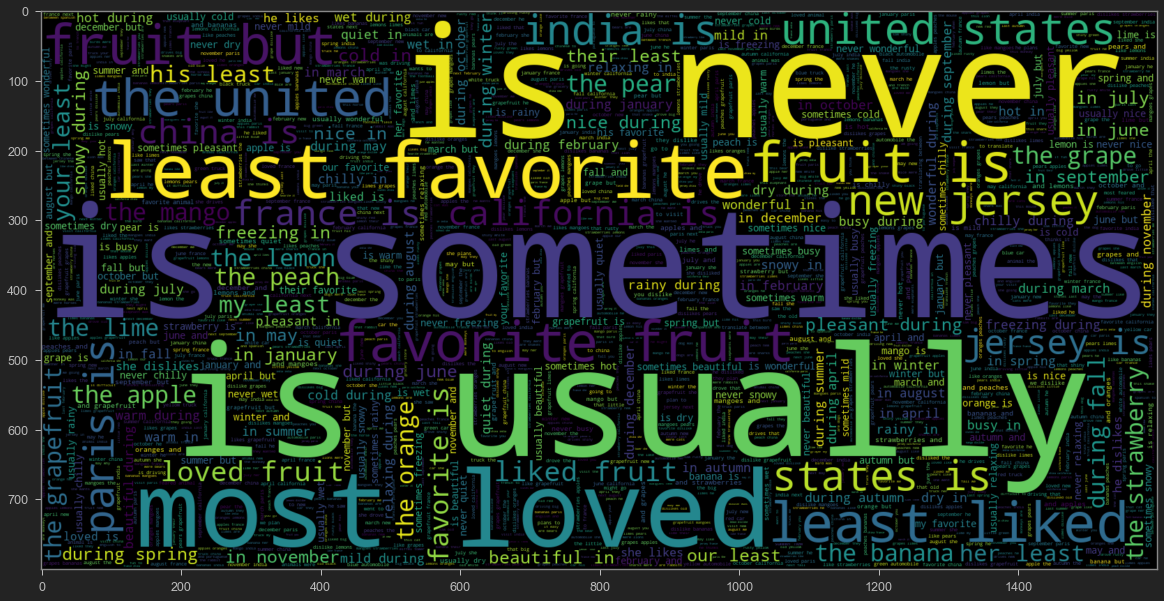

In [ ]:
# plot the word cloud for text that is Real
plt.figure(figsize = (20,20)) 
wc = WordCloud(max_words = 2000, width = 1600, height = 800 ).generate(" ".join(df.english))
plt.imshow(wc, interpolation = 'bilinear')

In [ ]:
df.english[0]
nltk.word_tokenize(df.english[0])

['new',
 'jersey',
 'is',
 'sometimes',
 'quiet',
 'during',
 'autumn',
 'and',
 'it',
 'is',
 'snowy',
 'in',
 'april']

In [ ]:
# Maximum length (number of words) per document. We will need it later for embeddings
maxlen_english = -1
for doc in df.english:
    tokens = nltk.word_tokenize(doc)
    if(maxlen_english < len(tokens)):
        maxlen_english = len(tokens)
print("The maximum number of words in any document = ", maxlen_english)

The maximum number of words in any document =  15


<a id="mini-challenge-4"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">Mini Challenge #4 (QUIZ!)</span>

- Perform similar data visualizations but for the french language instead
- What are the top 3 common french words?!
- What is the maximum number of words in any french document?

In [ ]:
# obtain the count of french words
words = []
for i in df['french']:
  for word in i.split():
    words.append(word)
words

['new',
 'jersey',
 'est',
 'parfois',
 'calme',
 'pendant',
 "l'",
 'automne',
 'et',
 'il',
 'est',
 'neigeux',
 'en',
 'avril',
 'les',
 'Ã©tats-unis',
 'est',
 'gÃ©nÃ©ralement',
 'froid',
 'en',
 'juillet',
 'et',
 'il',
 'gÃ¨le',
 'habituellement',
 'en',
 'novembre',
 'california',
 'est',
 'gÃ©nÃ©ralement',
 'calme',
 'en',
 'mars',
 'et',
 'il',
 'est',
 'gÃ©nÃ©ralement',
 'chaud',
 'en',
 'juin',
 'les',
 'Ã©tats-unis',
 'est',
 'parfois',
 'lÃ©gÃ¨re',
 'en',
 'juin',
 'et',
 'il',
 'fait',
 'froid',
 'en',
 'septembre',
 'votre',
 'moins',
 'aimÃ©',
 'fruit',
 'est',
 'le',
 'raisin',
 'mais',
 'mon',
 'moins',
 'aimÃ©',
 'est',
 'la',
 'pomme',
 'son',
 'fruit',
 'prÃ©fÃ©rÃ©',
 'est',
 "l'orange",
 'mais',
 'mon',
 'prÃ©fÃ©rÃ©',
 'est',
 'le',
 'raisin',
 'paris',
 'est',
 'relaxant',
 'en',
 'dÃ©cembre',
 'mais',
 'il',
 'est',
 'gÃ©nÃ©ralement',
 'froid',
 'en',
 'juillet',
 'new',
 'jersey',
 'est',
 'occupÃ©',
 'au',
 'printemps',
 'et',
 'il',
 'est',
 'jamais',
 'chaud

In [ ]:
french_words_counts = Counter(words)
french_words_counts

Counter({'new': 11047,
         'jersey': 11052,
         'est': 196809,
         'parfois': 37746,
         'calme': 7256,
         'pendant': 10741,
         "l'": 32917,
         'automne': 14727,
         'et': 59851,
         'il': 84079,
         'neigeux': 1867,
         'en': 105768,
         'avril': 8954,
         'les': 65255,
         'Ã©tats-unis': 11210,
         'gÃ©nÃ©ralement': 31292,
         'froid': 16794,
         'juillet': 8956,
         'gÃ¨le': 3622,
         'habituellement': 6215,
         'novembre': 8951,
         'california': 3061,
         'mars': 9023,
         'chaud': 16405,
         'juin': 9133,
         'lÃ©gÃ¨re': 63,
         'fait': 2916,
         'septembre': 8958,
         'votre': 9368,
         'moins': 27557,
         'aimÃ©': 25852,
         'fruit': 23626,
         'le': 35306,
         'raisin': 4852,
         'mais': 63987,
         'mon': 9403,
         'la': 49861,
         'pomme': 4848,
         'son': 16496,
         'prÃ©fÃ©rÃ©': 

In [ ]:
# sort the dictionary by values
french_words_counts = sorted(french_words_counts.items(), key = operator.itemgetter(1), reverse = True)

In [ ]:
french_words_counts

[('est', 196809),
 ('en', 105768),
 ('il', 84079),
 ('les', 65255),
 ('mais', 63987),
 ('et', 59851),
 ('la', 49861),
 ('parfois', 37746),
 ('jamais', 37215),
 ('le', 35306),
 ("l'", 32917),
 ('gÃ©nÃ©ralement', 31292),
 ('moins', 27557),
 ('aimÃ©', 25852),
 ('au', 25738),
 ('fruit', 23626),
 ('prÃ©fÃ©rÃ©', 23305),
 ('agrÃ©able', 17751),
 ('froid', 16794),
 ('son', 16496),
 ('chaud', 16405),
 ('de', 15070),
 ('plus', 14934),
 ('automne', 14727),
 ('mois', 14350),
 ('Ã', 13870),
 ('elle', 12056),
 ('citrons', 11679),
 ('paris', 11334),
 ('inde', 11277),
 ('Ã©tats-unis', 11210),
 ('france', 11170),
 ('jersey', 11052),
 ('new', 11047),
 ('chine', 10936),
 ('pendant', 10741),
 ('pamplemousse', 10140),
 ('mon', 9403),
 ('votre', 9368),
 ('juin', 9133),
 ('printemps', 9100),
 ('janvier', 9090),
 ('hiver', 9038),
 ('mars', 9023),
 ('Ã©tÃ©', 8999),
 ('mai', 8995),
 ('septembre', 8958),
 ('juillet', 8956),
 ('avril', 8954),
 ('novembre', 8951),
 ('dÃ©cembre', 8945),
 ('fÃ©vrier', 8942),
 ('octob

In [ ]:
# append the values to a list for visuaization purpose
french_words = []
french_counts = []
for i in range(len(french_words_counts)):
  french_words.append(french_words_counts[i][0])
  french_counts.append(french_words_counts[i][1])

In [ ]:
fig = px.bar(x = french_words, y = french_counts)
fig.show()

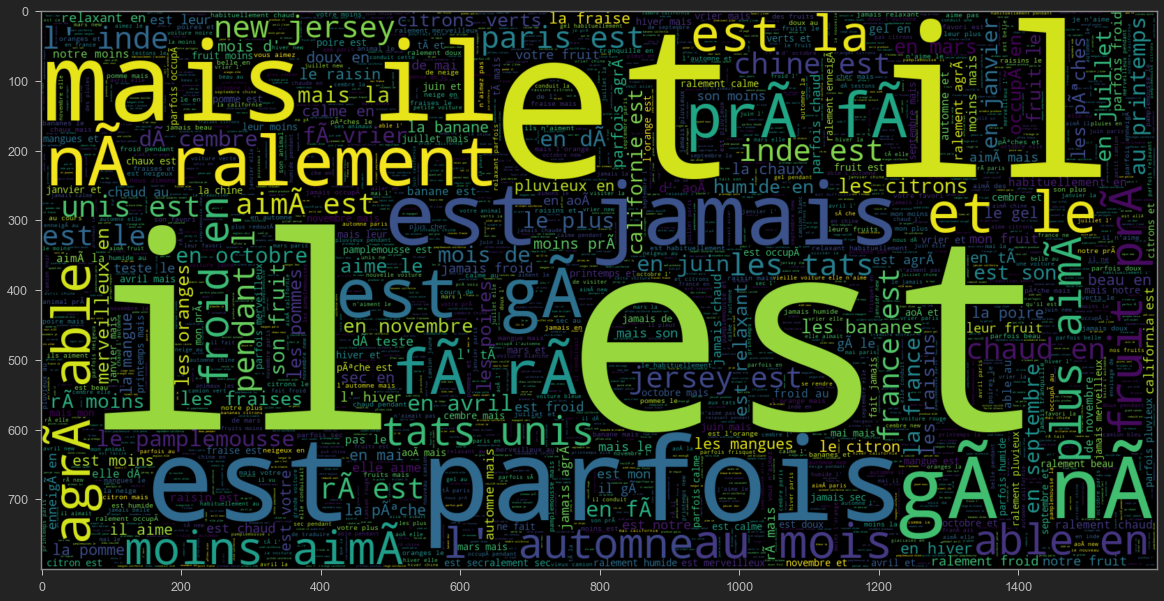

In [ ]:
# plot the word cloud for French
plt.figure(figsize = (20,20)) 
wc = WordCloud(max_words = 2000 , width = 1600 , height = 800).generate(" ".join(df.french))
plt.imshow(wc, interpolation = 'bilinear')

In [ ]:
# Maximum length (number of words) per document. We will need it later for embeddings
maxlen_french = -1
for doc in df.french:
    tokens = nltk.word_tokenize(doc)
    if(maxlen_french < len(tokens)):
        maxlen_french = len(tokens)
print("The maximum number of words in any document = ", maxlen_french)

The maximum number of words in any document =  24


<a id="task-5"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 5: Prepare the Data by Performing Tokenization and Padding</span>

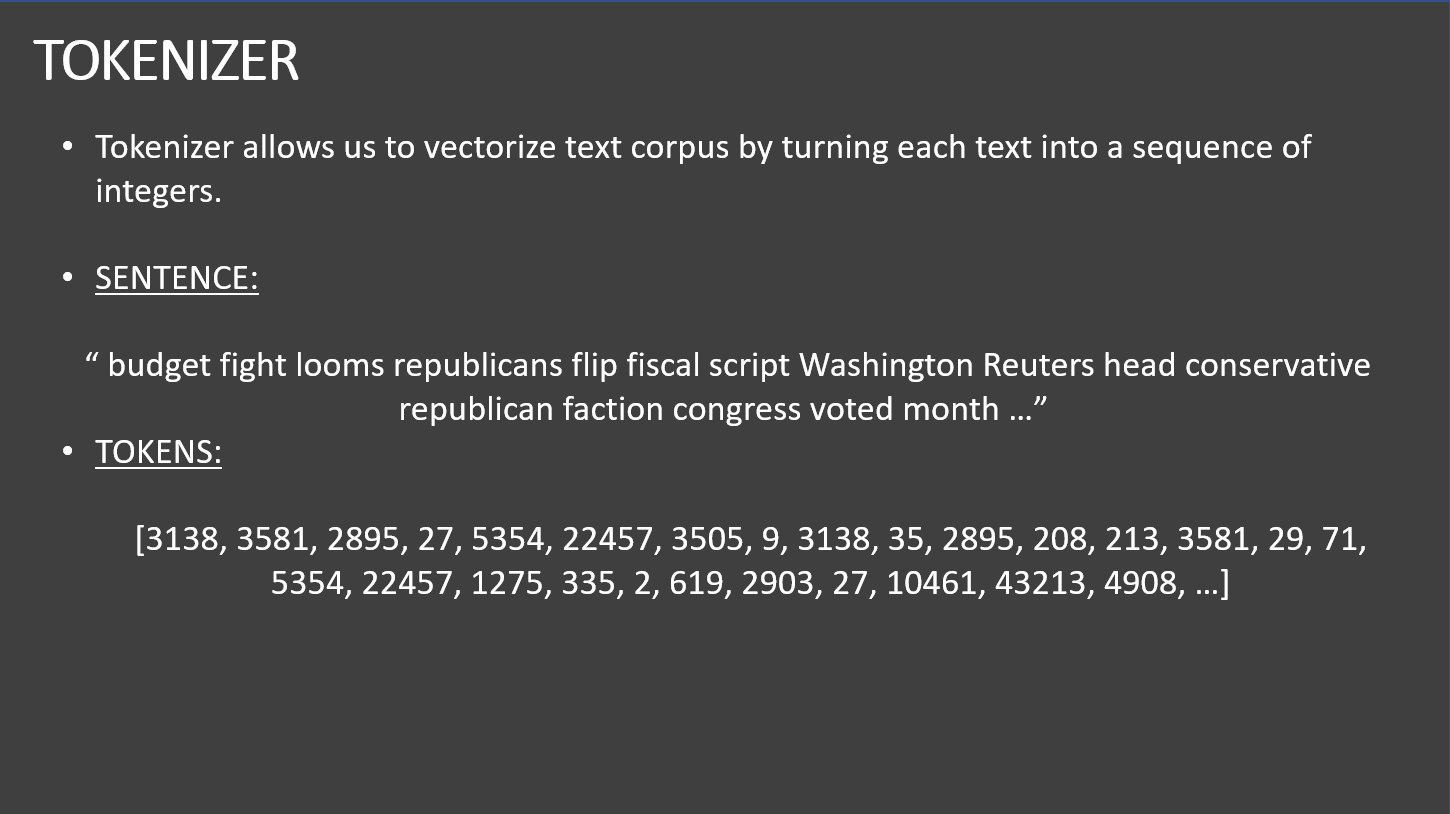

In [ ]:
def tokenize_and_pad(x, maxlen):
  #  a tokenier to tokenize the words and create sequences of tokenized words
  tokenizer = Tokenizer(char_level = False)
  tokenizer.fit_on_texts(x)
  sequences = tokenizer.texts_to_sequences(x)
  padded = pad_sequences(sequences, maxlen = maxlen, padding = 'post')
  return tokenizer, sequences, padded

In [ ]:
# tokenize and padding to the data 
x_tokenizer, x_sequences, x_padded = tokenize_and_pad(df.english, maxlen_english)
y_tokenizer, y_sequences, y_padded = tokenize_and_pad(df.french,  maxlen_french)

In [ ]:
# English vocab size derived from the fitted tokenizer (+1 for padding token 0)
english_vocab_size = len(x_tokenizer.word_index) + 1
print("Complete English Vocab Size:", english_vocab_size)


Complete English Vocab Size: 200


In [ ]:
# French vocab size derived from the fitted tokenizer (+1 for padding token 0)
french_vocab_size = len(y_tokenizer.word_index) + 1
print("Complete French Vocab Size:", french_vocab_size)


Complete French Vocab Size: 351


In [ ]:
print("The tokenized version for document\n", df.english[-1:].item(),"\n is : ", x_padded[-1:])

The tokenized version for document
 the orange is her favorite fruit  but the banana is your favorite  
 is :  [[ 5 84  1 32 11 13  6  5 87  1 29 11  0  0  0]]


In [ ]:
print("The tokenized version for document\n", df.french[-1:].item(),"\n is : ", y_padded[-1:])

The tokenized version for document
 l'orange est son fruit prÃ©fÃ©rÃ©  mais la banane est votre favori  
 is :  [[84  1 20 16 17  5  7 87  1 40 93  0  0  0  0  0  0  0  0  0  0  0  0  0]]


In [ ]:
# function to obtain the text from padded variables
def pad_to_text(padded, tokenizer):

    id_to_word = {id: word for word, id in tokenizer.word_index.items()}
    id_to_word[0] = ''

    return ' '.join([id_to_word[j] for j in padded])

In [ ]:
pad_to_text(y_padded[0], y_tokenizer)

"new jersey est parfois calme pendant l' automne et il est neigeux en avril          "

In [ ]:
# Train test split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_padded, y_padded, test_size = 0.1)

<a id="mini-challenge-5"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">Mini Challenge #5</span>

- Change the padding length so that both english and french have the same length

In [ ]:
# Mini Challenge #5: Unify padding length so both languages have identical max sequence length
shared_maxlen = max(maxlen_english, maxlen_french)
print(f"Unified maximum sequence length: {shared_maxlen}")

# Re-pad using shared maximum length
x_padded_unified = pad_sequences(x_sequences, maxlen=shared_maxlen, padding='post')
y_padded_unified = pad_sequences(y_sequences, maxlen=shared_maxlen, padding='post')
print("New English Padded Shape:", x_padded_unified.shape)
print("New French Padded Shape: ", y_padded_unified.shape)


<a id="task-6"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 6: Understand the Theory and Intuition Behind Recurrent Neural Networks and LSTM</span>

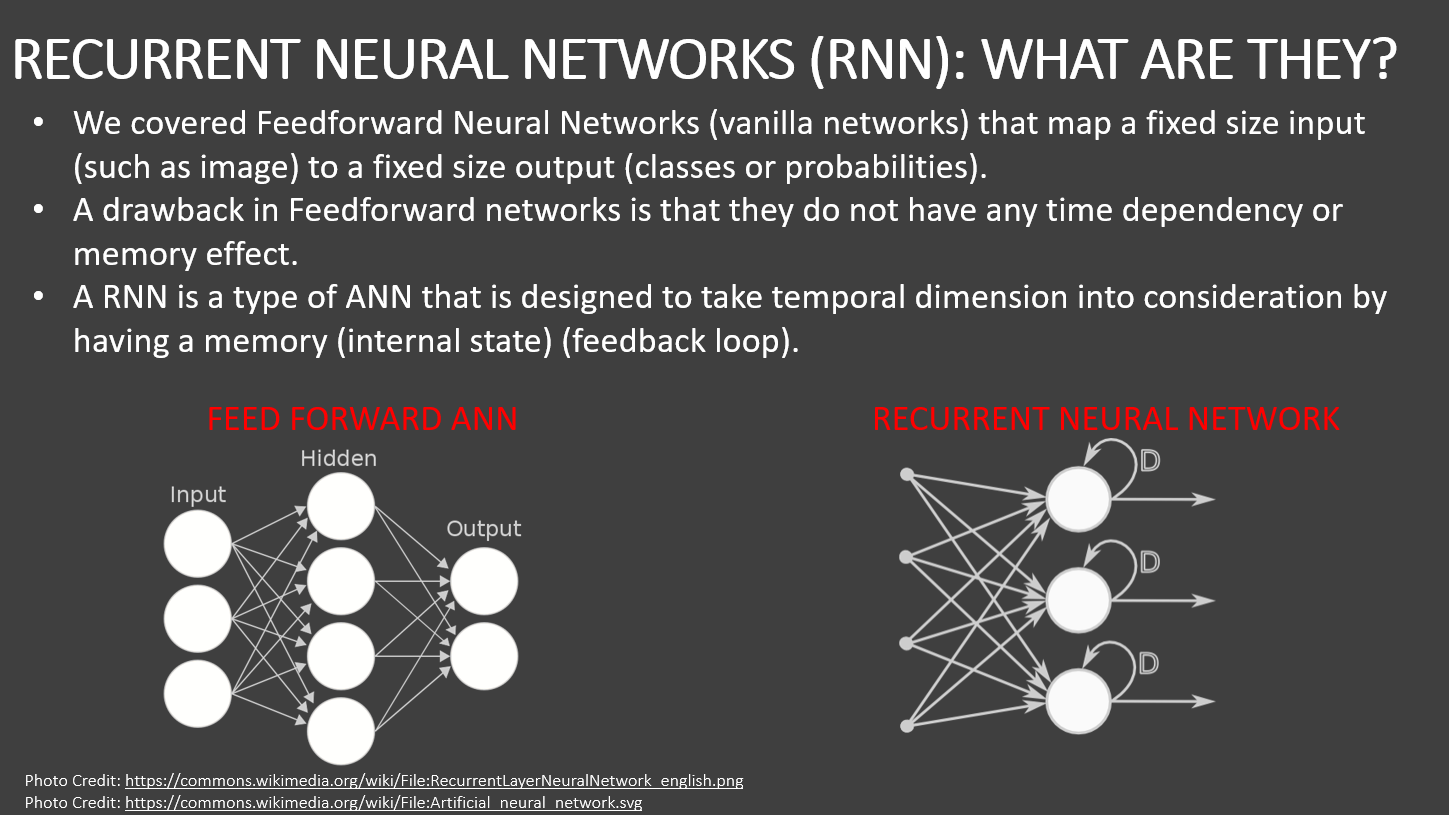

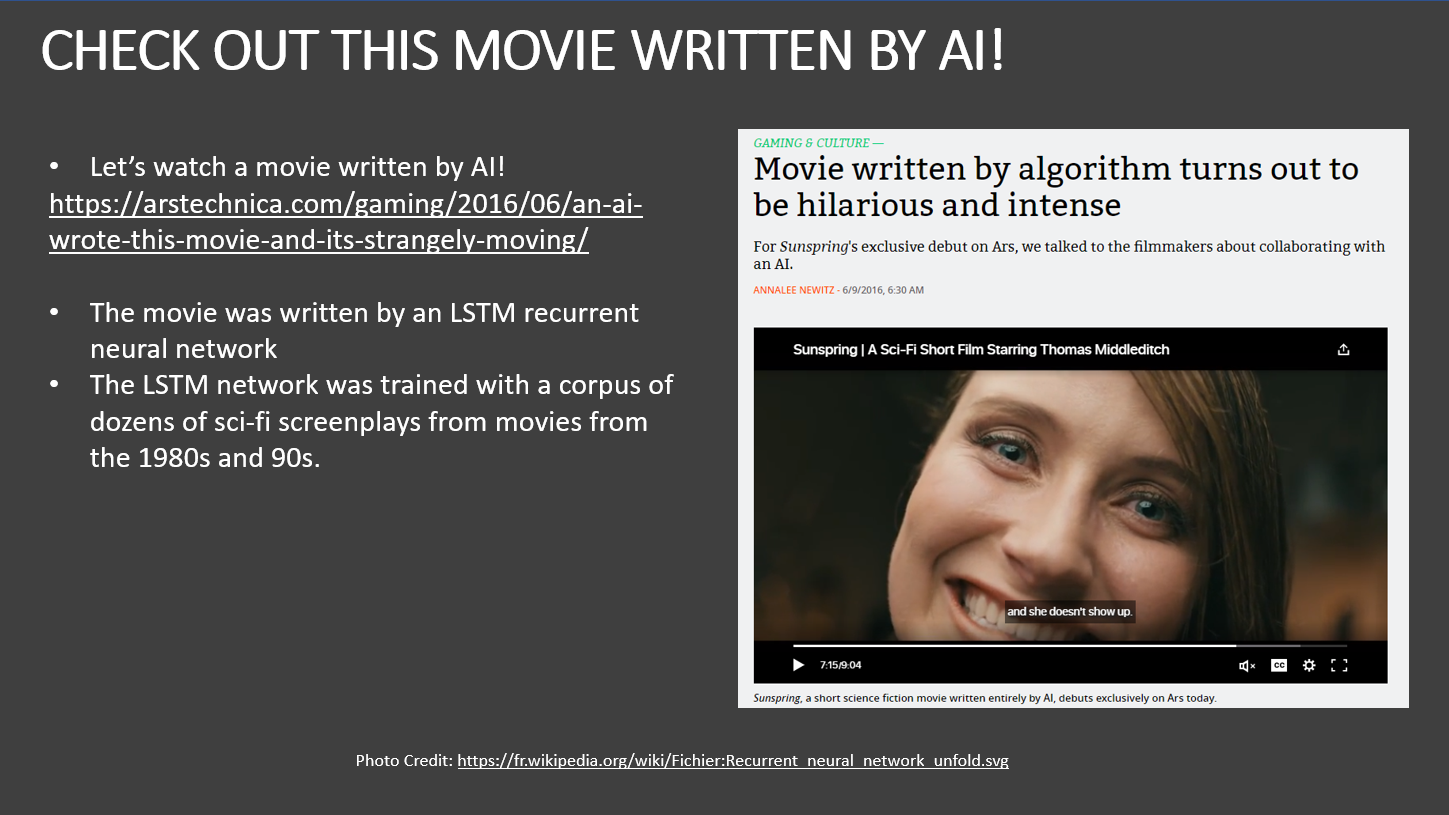

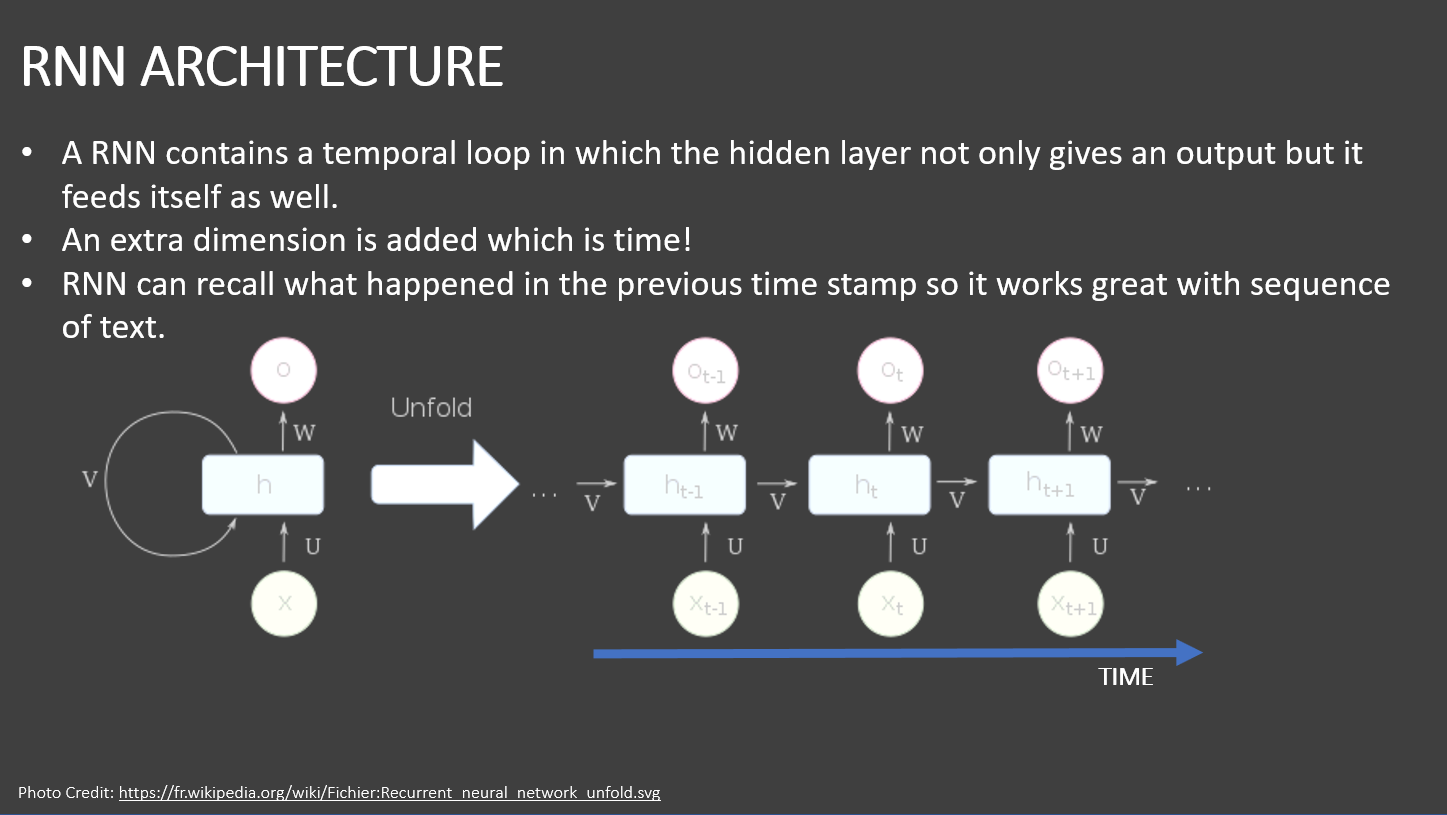

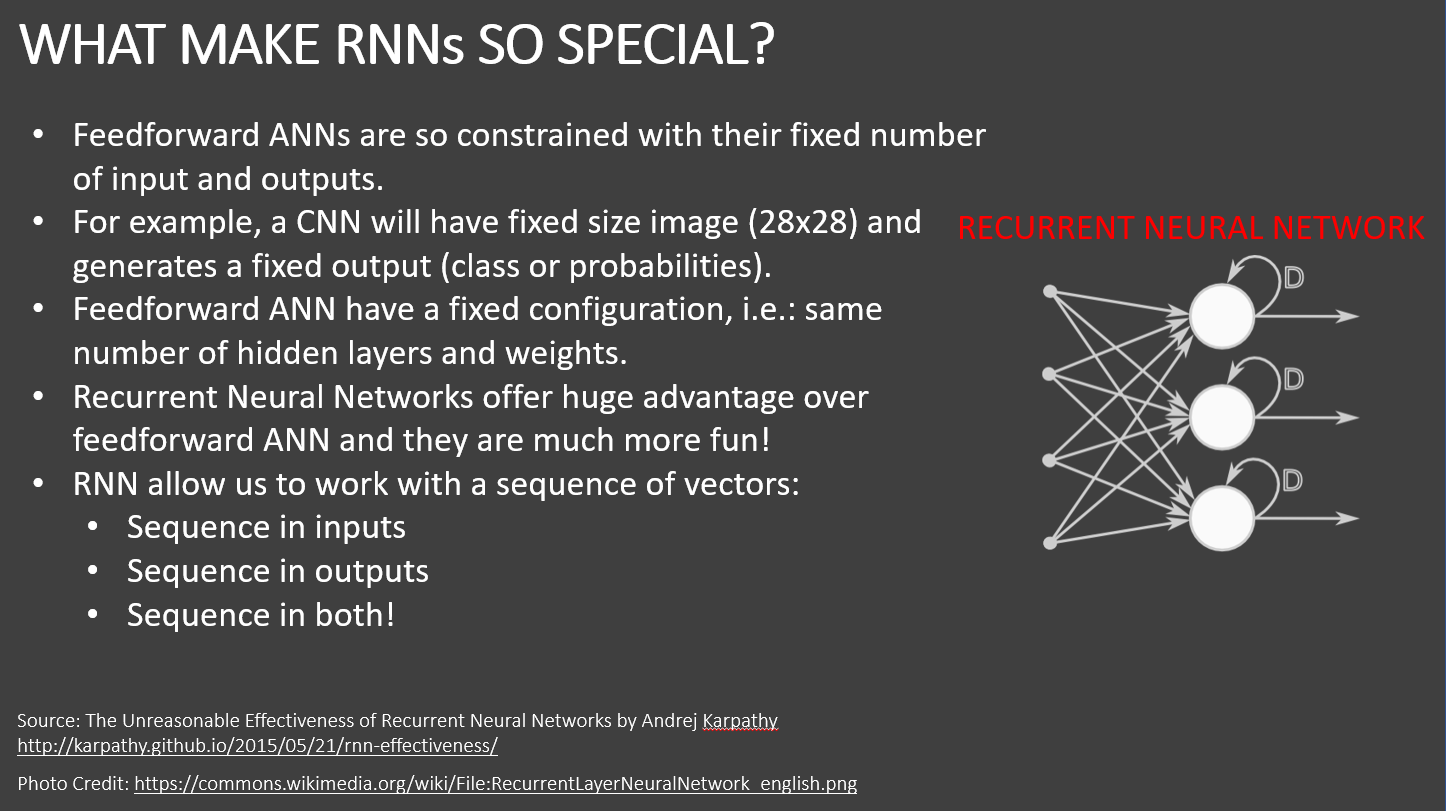

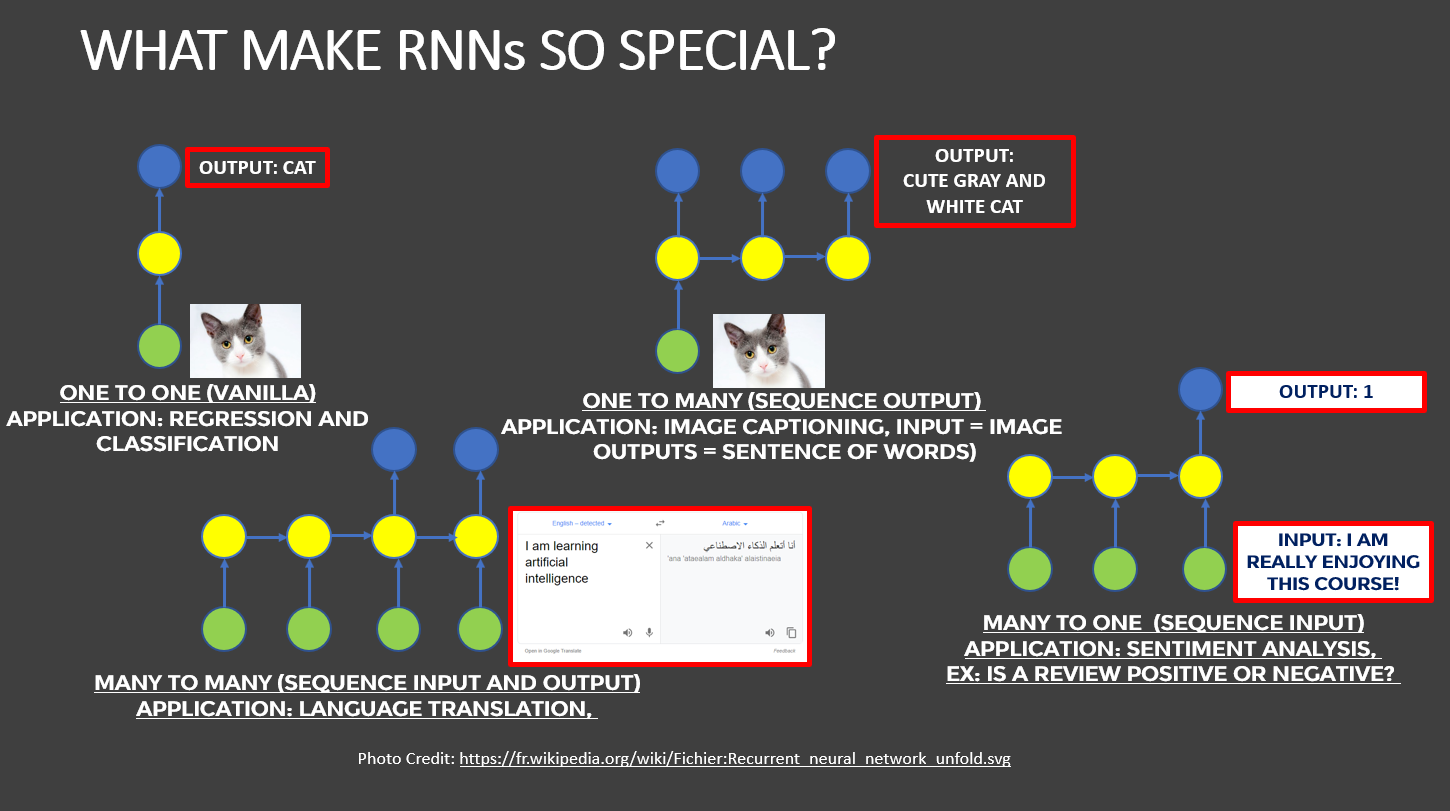

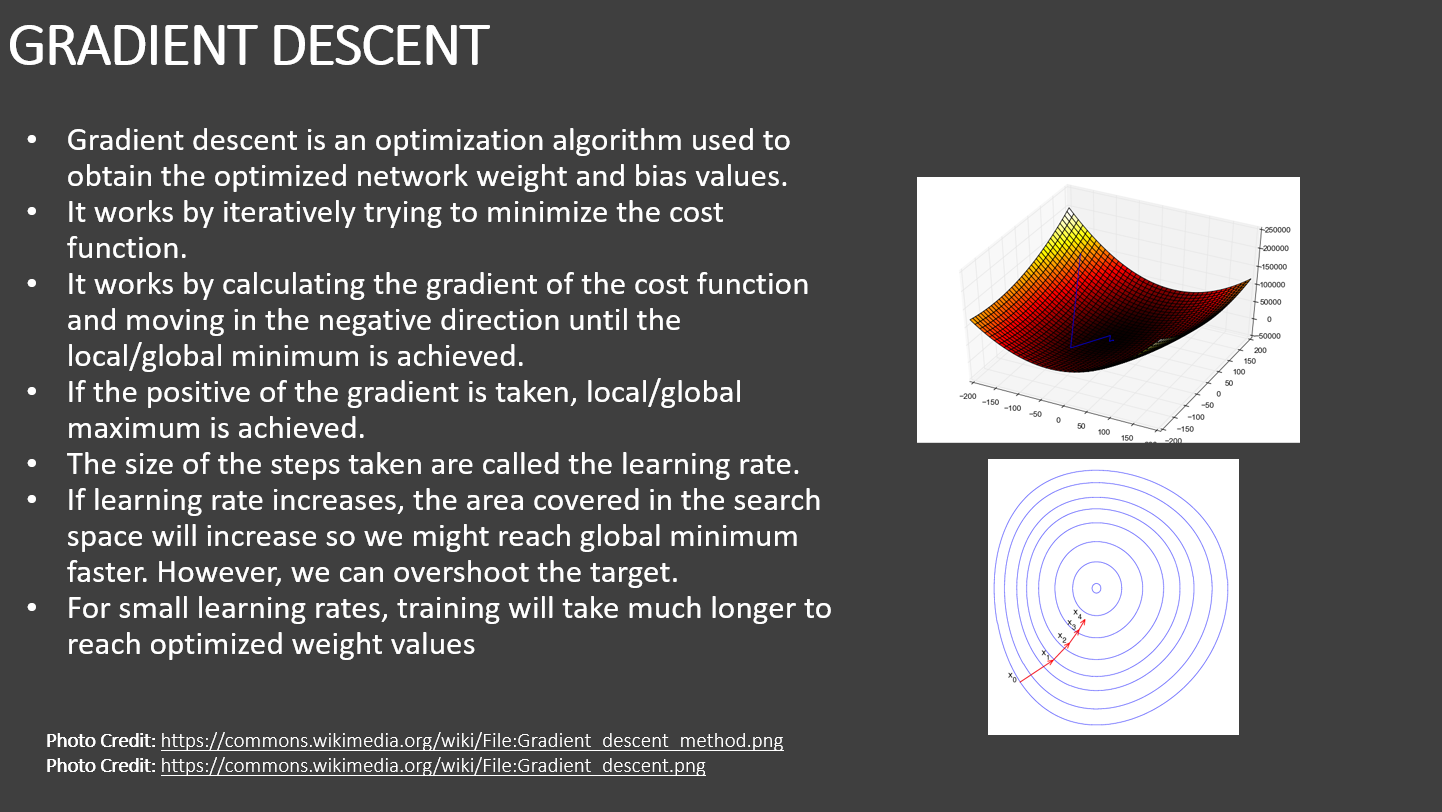

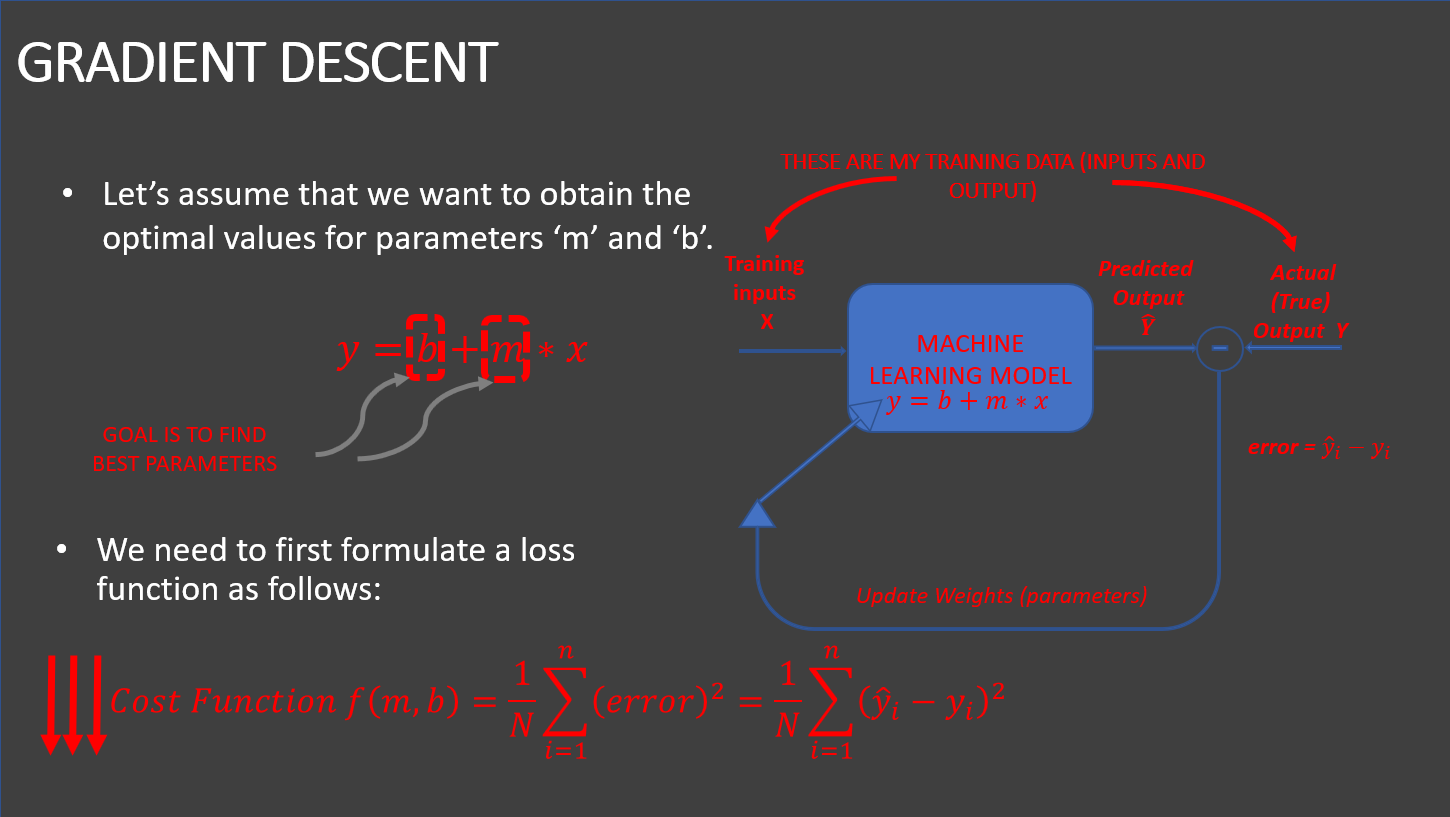

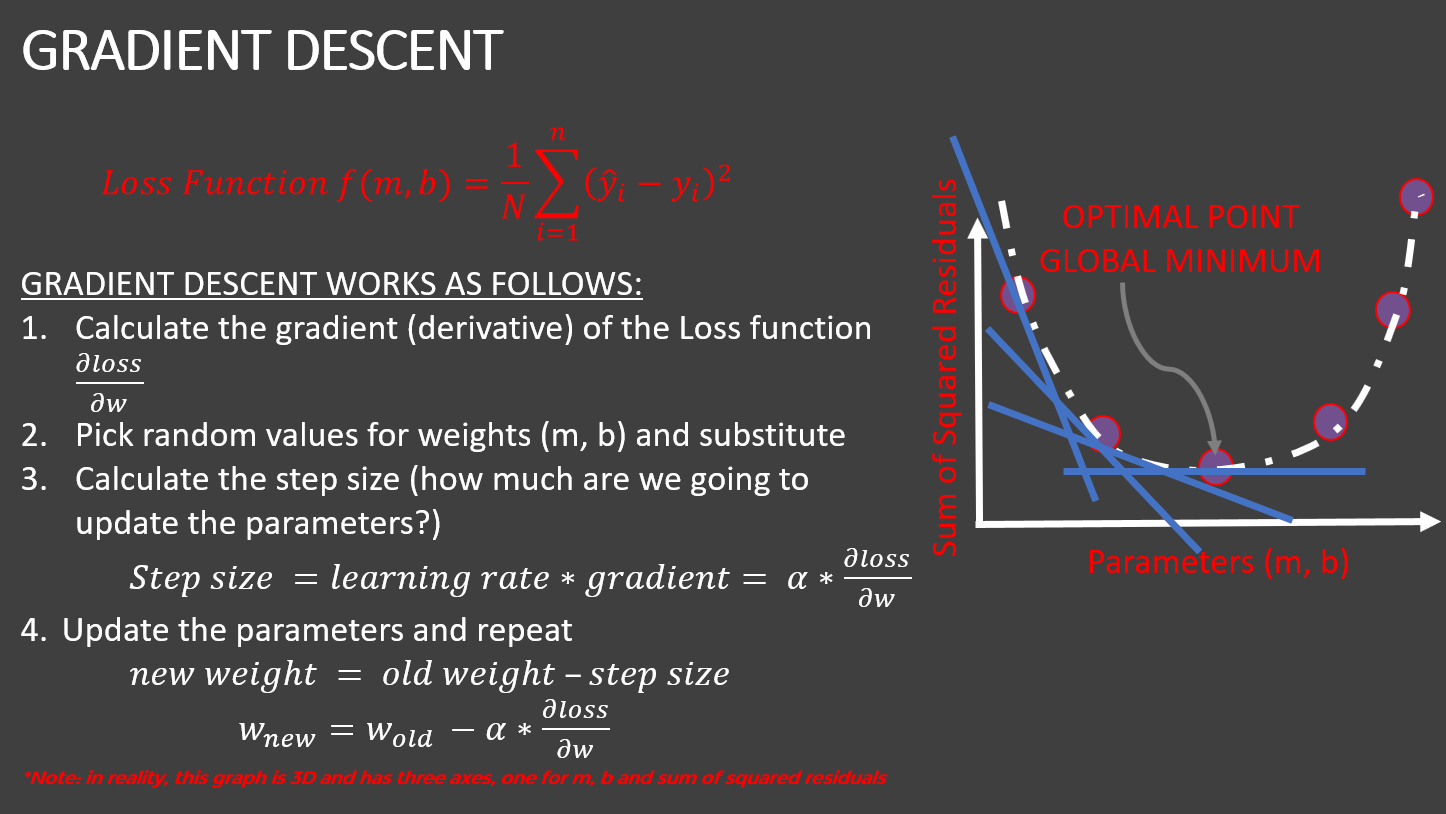

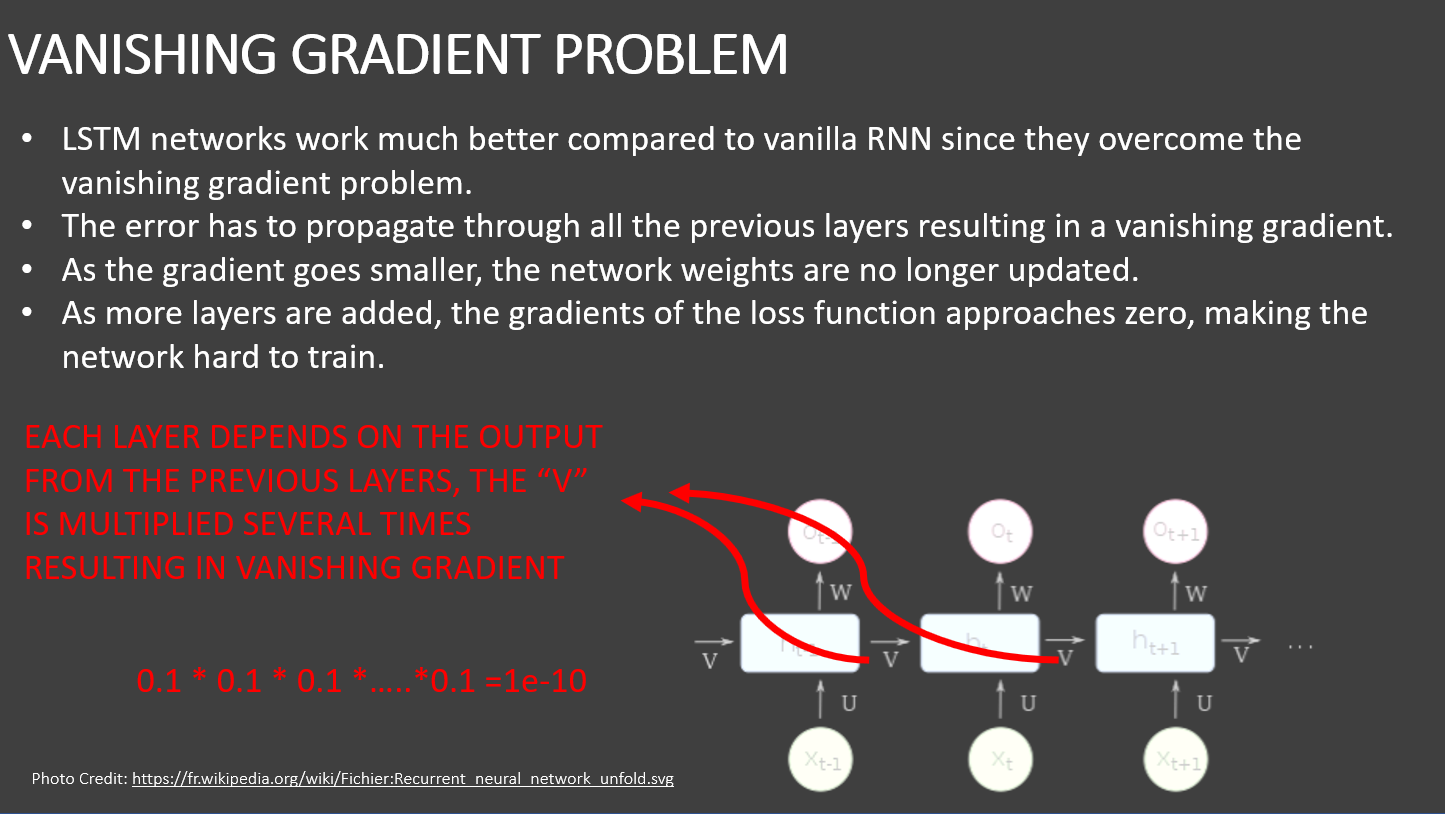

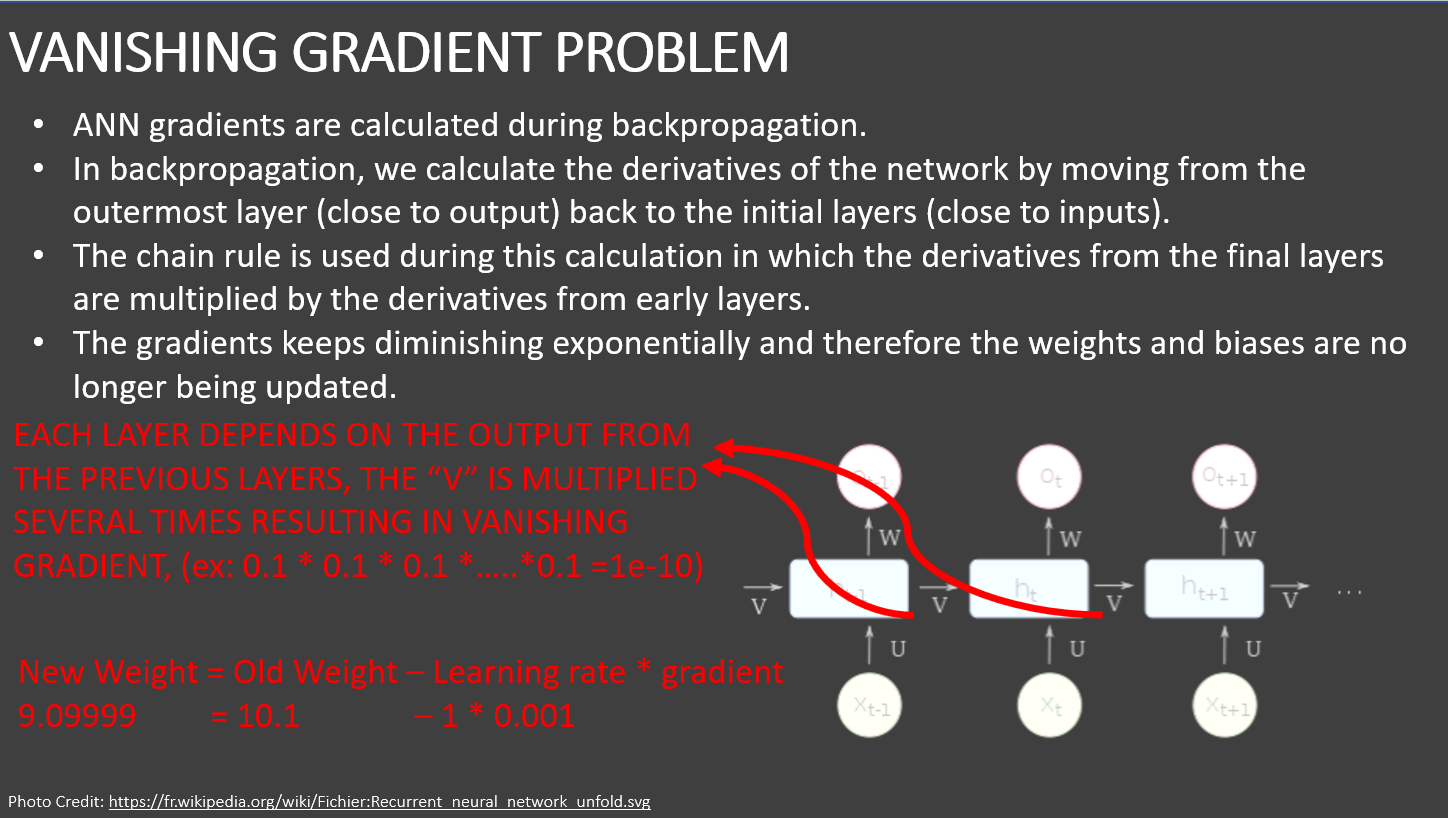

<a id="task-7"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 7: Understand the Intuition Behind Long Short Term Memory (LSTM) Networks</span>

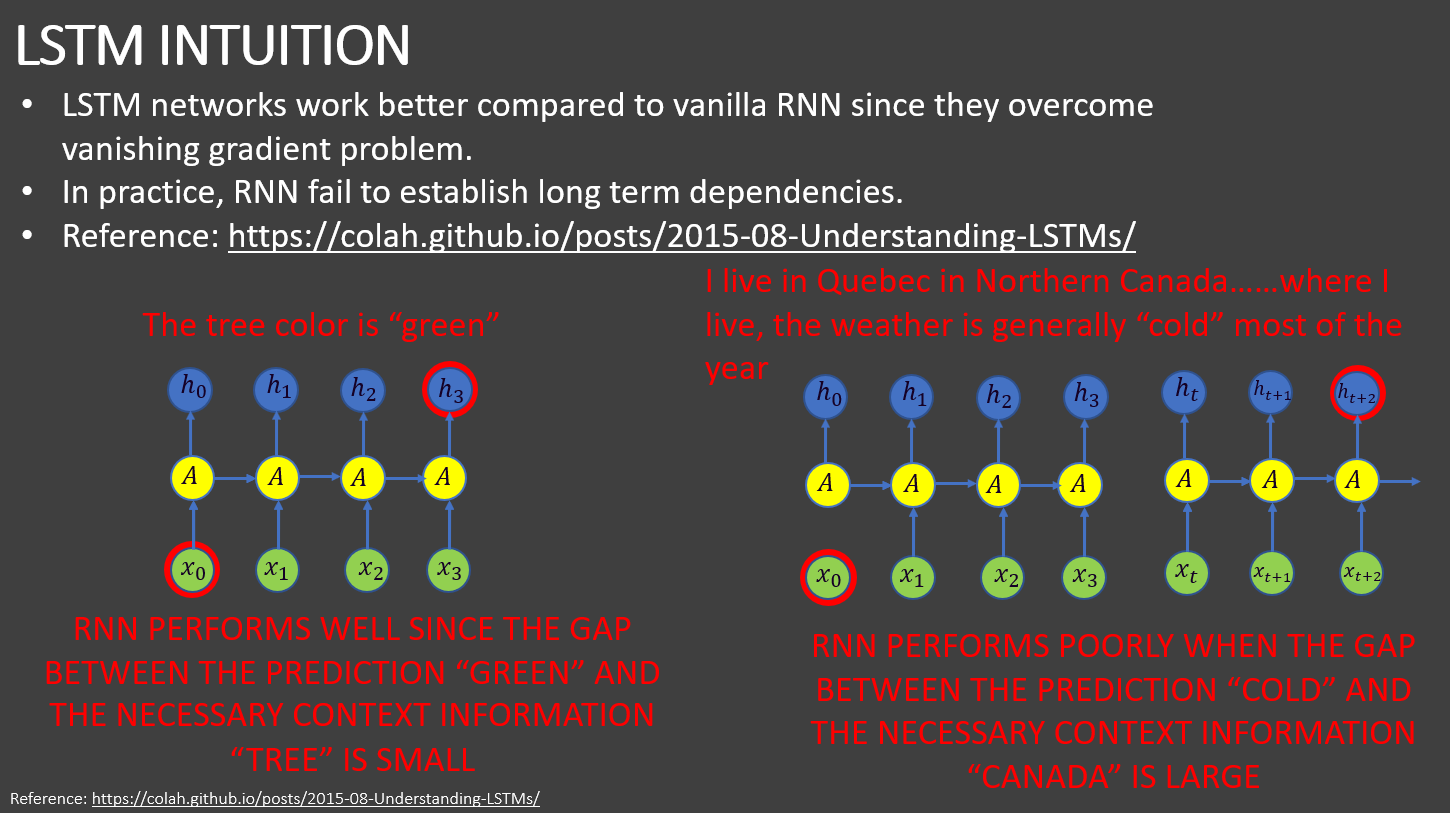

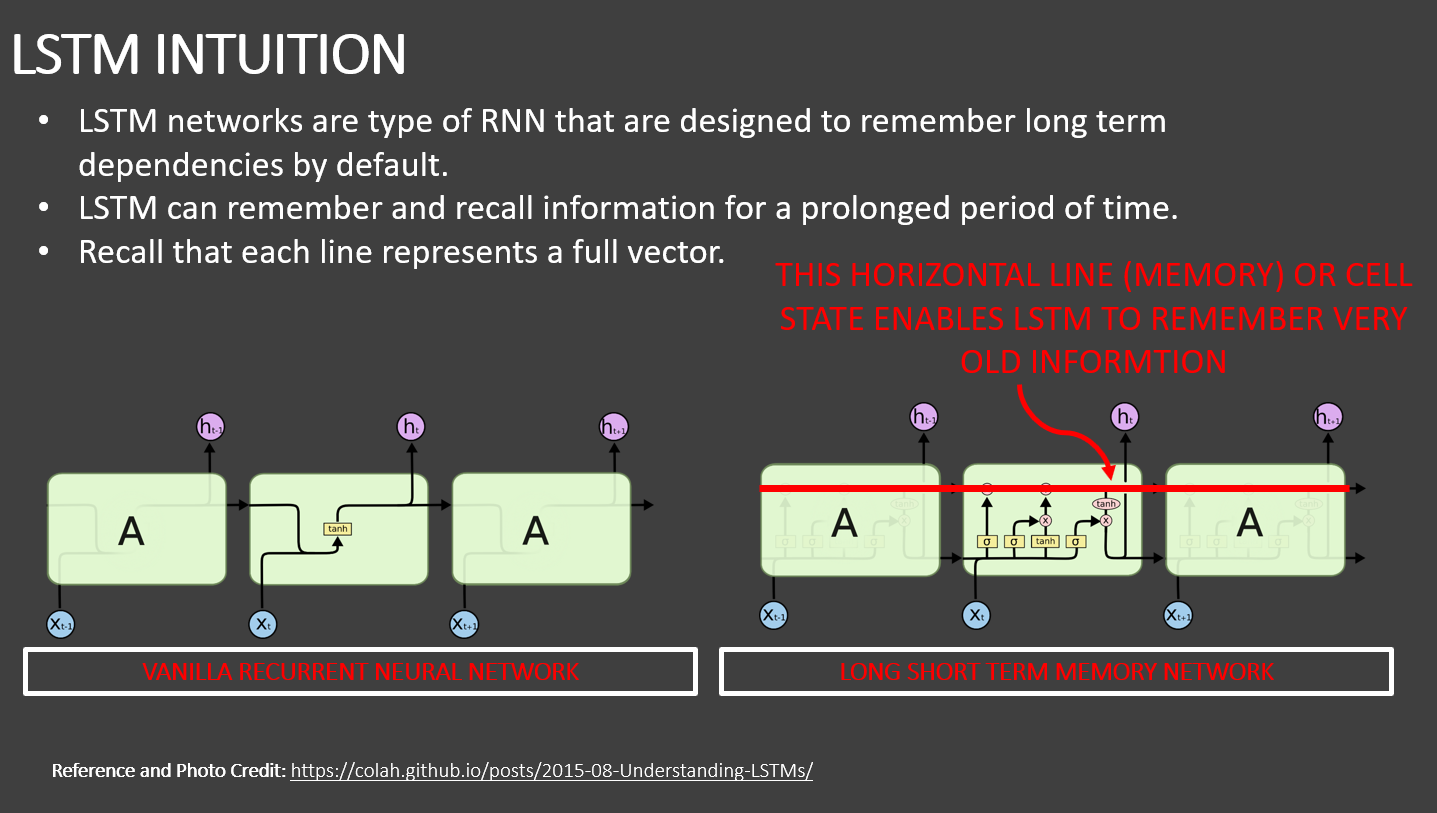

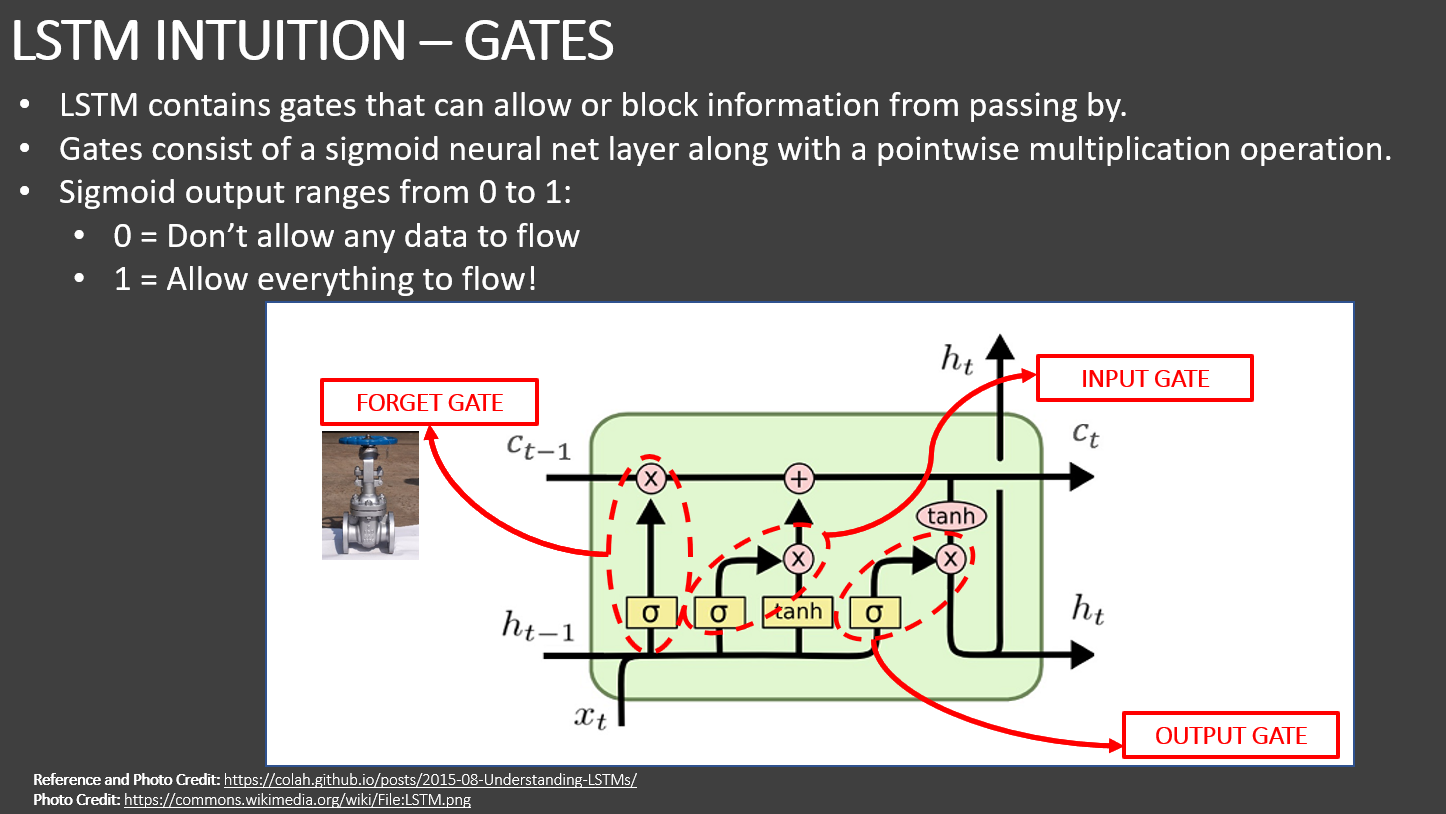

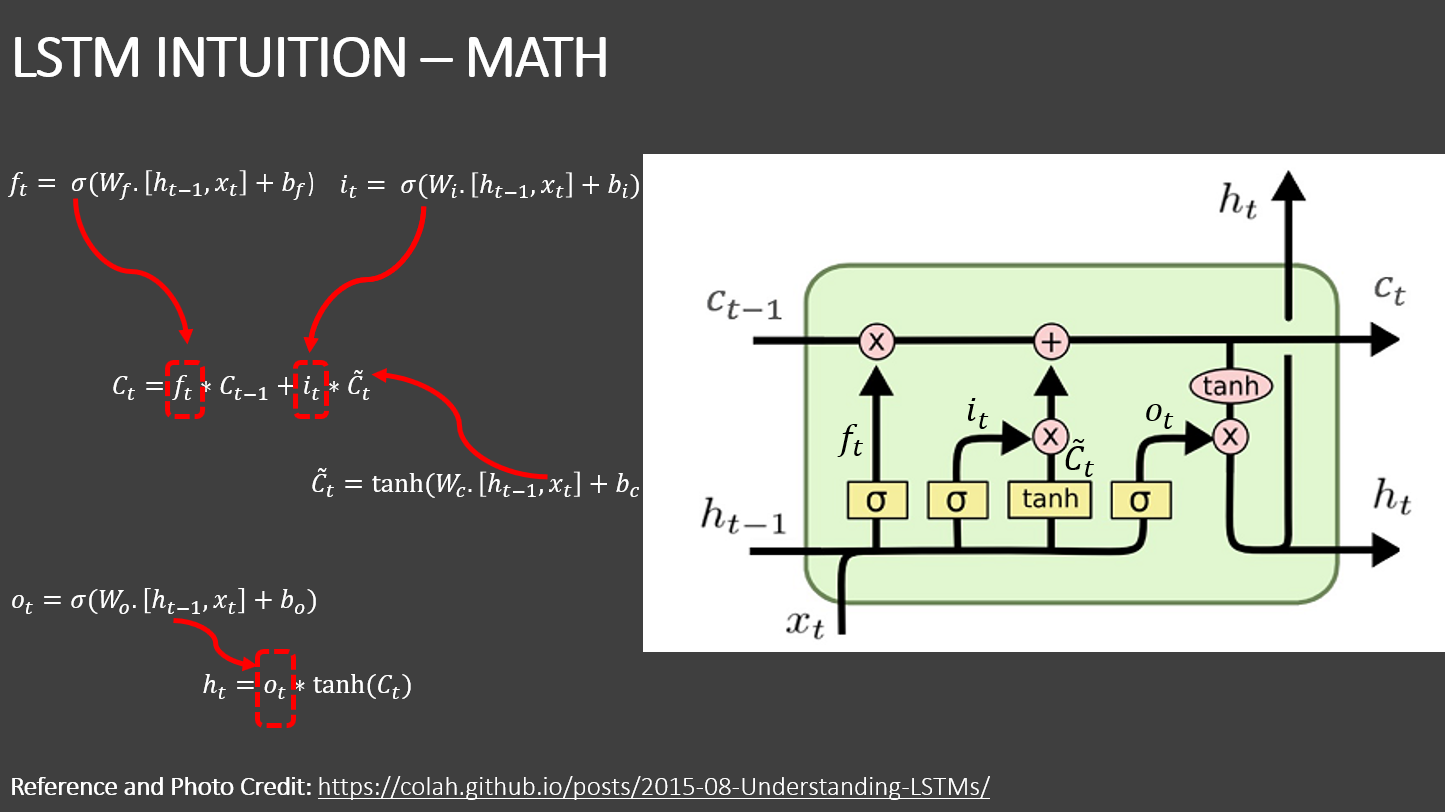

<a id="task-8"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 8: Build and Train the Model</span>

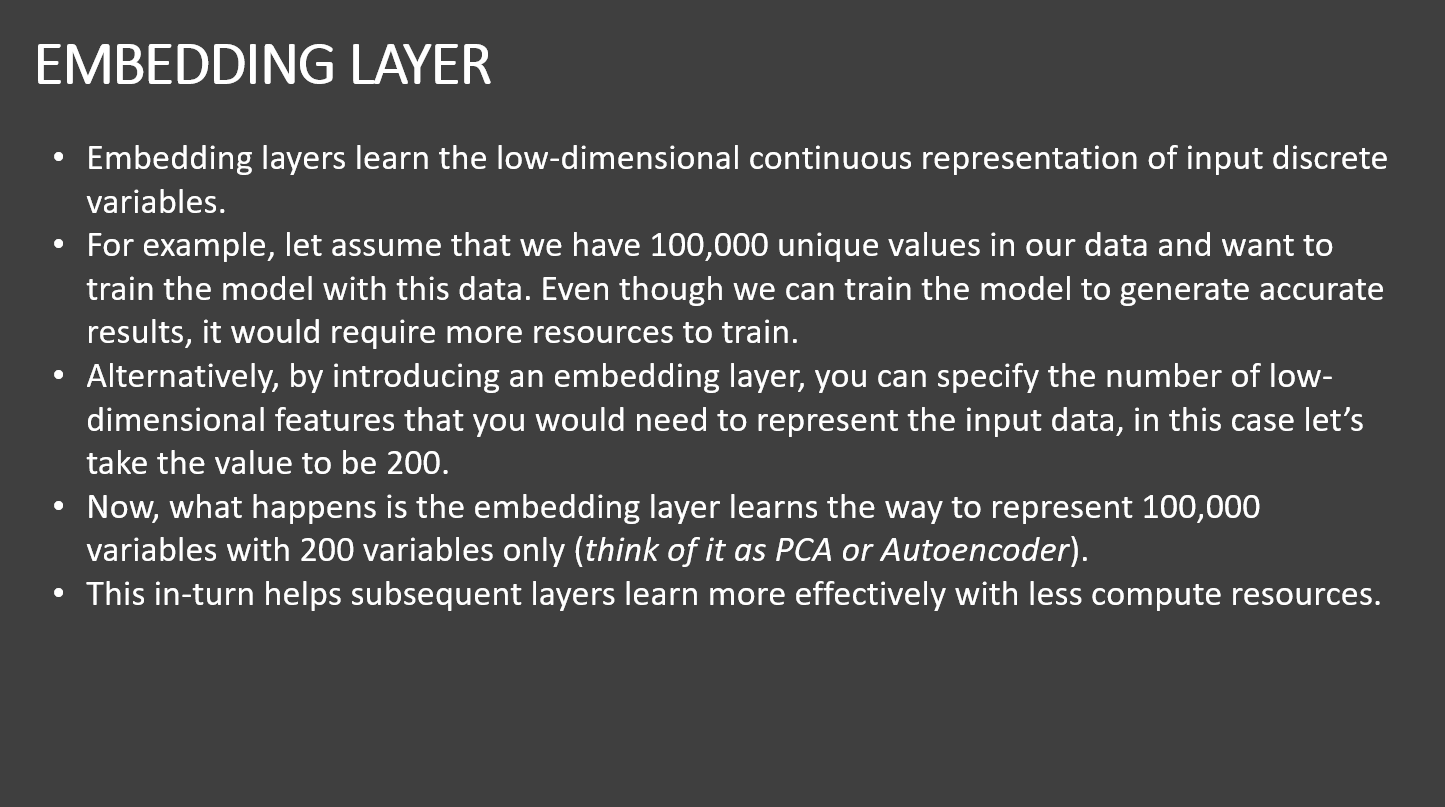

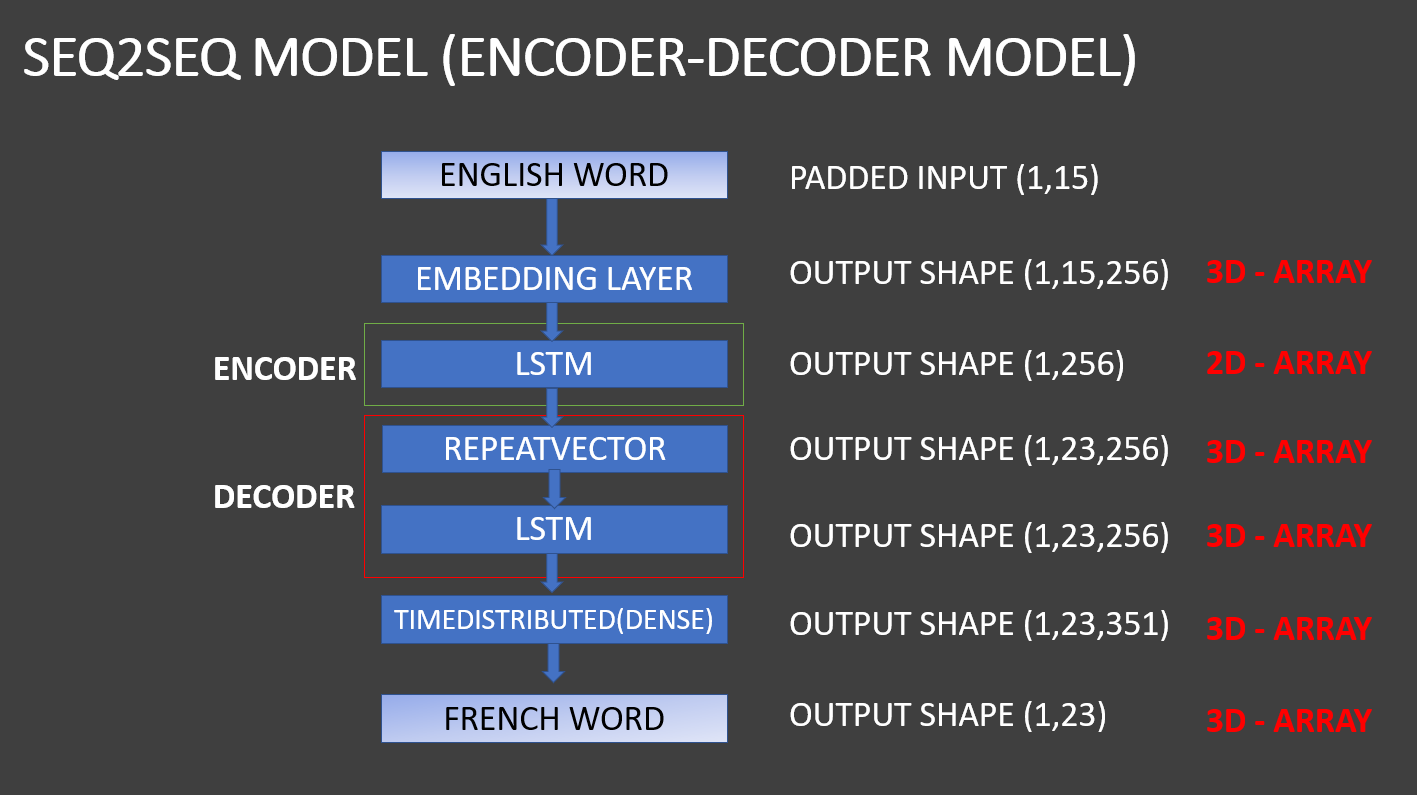

In [ ]:
# Sequential Model
model = Sequential()
# embedding layer
model.add(Embedding(input_dim=english_vocab_size, output_dim=256, input_shape=(maxlen_english,)))
# encoder
model.add(LSTM(256))
# decoder
# repeatvector repeats the input for the desired number of times to change
# 2D-array to 3D array. For example: (1,256) to (1,23,256)
model.add(RepeatVector(maxlen_french))
model.add(LSTM(256, return_sequences=True))
model.add(TimeDistributed(Dense(french_vocab_size, activation='softmax')))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 15, 256)           51200     
_________________________________________________________________
lstm (LSTM)                  (None, 256)               525312    
_________________________________________________________________
repeat_vector (RepeatVector) (None, 24, 256)           0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 24, 256)           525312    
_________________________________________________________________
time_distributed (TimeDistri (None, 24, 351)           90207     
Total params: 1,192,031
Trainable params: 1,192,031
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# Change the shape of target from 2D to 3D safely (idempotent so re-running cell doesn't inflate dimensions)
y_train = np.asarray(y_train)
if y_train.ndim == 2:
    y_train = np.expand_dims(y_train, axis=2)
print("y_train shape:", y_train.shape)

(124074, 24, 1)

In [ ]:
# train the model
history = model.fit(x_train, y_train, batch_size=1024, validation_split=0.1, epochs=10)

In [ ]:
# save the model
model.save("weights.h5")

<a id="mini-challenge-6"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">Mini Challenge #6</span>

- Train the model with different embedding output dimension and comment on model performance during training


In [ ]:
# Mini Challenge #6: Comparison of Model Parameters with Different Embedding Dimensions
# (Using simple basic colors: 'blue' and 'orange')
embedding_dims = [64, 128, 256, 512]
param_counts = []

for dim in embedding_dims:
    test_model = Sequential([
        Embedding(input_dim=english_vocab_size, output_dim=dim, input_shape=(maxlen_english,)),
        LSTM(256),
        RepeatVector(maxlen_french),
        LSTM(256, return_sequences=True),
        TimeDistributed(Dense(french_vocab_size, activation='softmax'))
    ])
    param_counts.append(test_model.count_params())

plt.figure(figsize=(7, 4))
bars = plt.bar([str(d) for d in embedding_dims], [p/1e6 for p in param_counts], color='blue', edgecolor='black', width=0.5)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.05, f"{yval:.2f}M", ha='center', va='bottom', fontweight='bold')
plt.title('Total Model Parameters vs Embedding Dimension', fontsize=12, fontweight='bold')
plt.xlabel('Embedding Output Dimension', fontsize=10)
plt.ylabel('Trainable Parameters (Millions)', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

<a id="task-9"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 9: Assess Trained Model Performance</span>

In [ ]:
# function to make prediction
def prediction(x, x_tokenizer=x_tokenizer, y_tokenizer=y_tokenizer):
    x = np.asarray(x)
    if x.ndim == 1:
        x = np.expand_dims(x, axis=0)
    predictions = model.predict(x, verbose=0)[0]
    id_to_word = {id: word for word, id in y_tokenizer.word_index.items()}
    id_to_word[0] = ''
    return ' '.join([id_to_word.get(j, '') for j in np.argmax(predictions, axis=1)]).strip()


In [ ]:
for i in range(5):

  print('Original English word - {}\n'.format(pad_to_text(x_test[i], x_tokenizer)))
  print('Original French word - {}\n'.format(pad_to_text(y_test[i], y_tokenizer)))
  print('Predicted French word - {}\n\n\n\n'.format(prediction(x_test[i:i+1])))

In [ ]:
# ====================================================================
# Plot 3: Sequence Length Alignment (Input English vs Predicted French)
# (Using simple basic colors: 'blue' and 'green')
# ====================================================================
sample_indices = range(min(10, len(x_test)))
en_word_counts = [len(pad_to_text(x_test[i], x_tokenizer).split()) for i in sample_indices]
fr_pred_counts = [len(prediction(x_test[i:i+1]).split()) for i in sample_indices]

x_axis = np.arange(len(sample_indices))
width = 0.35

plt.figure(figsize=(10, 4))
plt.bar(x_axis - width/2, en_word_counts, width, label='English Input Length', color='blue', edgecolor='black')
plt.bar(x_axis + width/2, fr_pred_counts, width, label='Predicted French Length', color='green', edgecolor='black')
plt.title('Token Length Alignment Across Sample Translations', fontsize=12, fontweight='bold')
plt.xlabel('Test Sample Index', fontsize=10)
plt.ylabel('Word Count', fontsize=10)
plt.xticks(x_axis, [f'Sample {i+1}' for i in sample_indices])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

<a id="task-9-quiz"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">Task 9.1: Interactive Quiz, Missing Code & Translation Puzzle</span>

Reinforce your understanding of Sequence-to-Sequence (Seq2Seq) neural translation with an architectural quiz, fill-in-the-missing-code exercise, and interactive French translation tester.


### Concept Check: Sequence-to-Sequence Translation

**1. How does the Encoder-Decoder architecture pass information from the English input to the French output?**
- **A)** It writes words to a shared temporary text file
- **B)** The Encoder LSTM compresses the variable-length sentence into a fixed-size latent state vector, which the Decoder unpacks into the target language
- **C)** It passes characters as random integers
- **D)** Through linear regression coefficients

<details>
<summary><b>View Answer & Explanation</b></summary>

> **Correct Answer: B**  
> The Encoder processes the source tokens sequentially and compresses their meaning into a bottleneck context vector. The Decoder uses this context representation as its starting point to generate translated tokens sequentially.
</details>

---

**2. What is the main advantage of an `Embedding` layer over one-hot encoding?**
- **A)** Embeddings represent words as dense continuous vectors that capture semantic similarity (e.g., words with similar meanings have similar vectors)
- **B)** Embeddings make vocabulary sizes larger
- **C)** One-hot encoding cannot be trained with backpropagation
- **D)** Embeddings don't require any trainable parameters

<details>
<summary><b>View Answer & Explanation</b></summary>

> **Correct Answer: A**  
> One-hot encoding creates sparse, orthogonal vectors of length $V$ where all words are equidistant. Dense embeddings project words into a continuous $D$-dimensional space where semantic relationships can be learned.
</details>

---

**3. Why do we set `mask_zero=True` on the Embedding layer?**
- **A)** To delete all numbers in the dataset
- **B)** To signal to downstream LSTM layers to skip zero-padded time steps during computation and loss evaluation
- **C)** To reset model weights to zero after each batch
- **D)** To clamp outputs to positive values

<details>
<summary><b>View Answer & Explanation</b></summary>

> **Correct Answer: B**  
> `mask_zero=True` prevents the network from learning spurious patterns from the padding token (index 0), focusing gradient updates exclusively on actual words.
</details>


In [ ]:
# Preprocessing helper for user sentence inference
def preprocess_english_text(sentence, tokenizer, max_len):
    """Converts a raw English sentence into the padded sequence format required by the model."""
    sequences = tokenizer.texts_to_sequences([sentence])
    padded = pad_sequences(sequences, maxlen=max_len, padding='post')
    return padded

# Example test
test_phrase = "new jersey is sometimes quiet"
print(f"Raw text:       '{test_phrase}'")
print(f"Padded vector:  {preprocess_english_text(test_phrase, x_tokenizer, maxlen_english)}")

In [ ]:
# Test translations on custom sample phrases
def translate(sentence):
    padded_input = preprocess_english_text(sentence, x_tokenizer, maxlen_english)
    raw_french = prediction(padded_input)
    clean_french = ' '.join(raw_french.split())
    return clean_french

sample_phrases = [
    "new jersey is sometimes quiet during autumn",
    "the united states is usually chilly during july",
    "california is usually quiet during winter"
]

print("Sample Translations:")
for phrase in sample_phrases:
    print(f"EN: {phrase}")
    print(f"FR: {translate(phrase)}\n")

<a id="practice-solutions"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Practice Solutions (Congratulations!)</span>

<a id="solution-1"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">Mini Challenge #1 Solution</span>

- Explore the 'english' and 'french' data and indicate how many samples is included. 

In [ ]:
# data containing english text
df_english
# data containing french text
df_french

# dataframe information
df_english.info
# dataframe information
df_french.info()

# check for null values
df_english.isnull().sum()
# check for null values
df_french.isnull().sum()

<a id="solution-2"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">Mini Challenge #2 Solution</span>

- Concatenate both dataframes and indicate how many records are present

In [ ]:
# Concatenate English and French datasets
df = pd.concat([df_english, df_french], axis = 1)
df

In [ ]:
print("Total English Records = {}".format(len(df['english'])))
print("Total French Records = {}".format(len(df['french'])))

<a id="solution-3"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">Mini Challenge #3 Solution</span>

- How many unique words are available in the english and french dictionairies?

In [ ]:
# function to get the list of unique words
def get_label_superset(x, word_list):
    for label in x.split():
        if label not in word_list:
            word_list.append(label)
            
            
df['english'].apply(lambda x: get_label_superset(x, english_words))
df['french'].apply(lambda x: get_label_superset(x, french_words))

# number of unique words in english
total_english_words  = len(english_words)
total_english_words

# number of unique words in french
total_french_words = len(french_words)
total_french_words

<a id="solution-4"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">Mini Challenge #4 Solution</span>

- Perform similar data visualizations but for the french language instead
- What are the top 3 common french words?!
- What is the maximum number of words in any french document?

In [ ]:
# Solution to Mini Challenge #4 (QUIZ!):
# 1. Top 3 common French words
print('Top 3 Common French Words:')
for word, count in french_words_counts[:3]:
    print(f"   '{word}': {count:,} occurrences")

# 2. Maximum number of words in any French document
print(f"\nMaximum number of words in any French document: {maxlen_french} words")

# 3. Visualization using simple basic colors ('green')
top_10_fr_words = [pair[0] for pair in french_words_counts[:10]][::-1]
top_10_fr_counts = [pair[1] for pair in french_words_counts[:10]][::-1]

plt.figure(figsize=(9, 4))
plt.barh(top_10_fr_words, top_10_fr_counts, color='green', edgecolor='black')
plt.title('Top 10 French Words in Vocabulary', fontsize=12, fontweight='bold')
plt.xlabel('Frequency', fontsize=10)
plt.ylabel('Word', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

<a id="solution-5"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">Mini Challenge #5 Solution</span>

- Change the padding length so that both english and french have the same length and retrain the model

In [ ]:
# tokenize and padding to the data 
x_tokenizer, x_sequences, x_padded = tokenize_and_pad(df.english, maxlen_french)
y_tokenizer, y_sequences, y_padded = tokenize_and_pad(df.french,  maxlen_french)

<a id="solution-6"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">Mini Challenge #6 Solution</span>

- Train the model with different embedding output dimension and comment on model


In [ ]:
# Sequential Model
model = Sequential()

# embedding layer
model.add(Embedding(input_dim=english_vocab_size, output_dim=128, input_shape=(maxlen_english,)))
model.add(LSTM(256))
model.add(RepeatVector(maxlen_french))
model.add(LSTM(256, return_sequences=True))
model.add(TimeDistributed(Dense(french_vocab_size, activation='softmax')))
model.compile(optimizer=Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()
